# Super Micro Forensic Analysis: Earnings Quality and Accounting Red Flags

**30 June 2025. Super Micro Computer has filed its delayed fiscal 2024 10-K: a clean opinion on the numbers, an adverse
one on internal controls, no restatement. A year earlier it was one of the market's best performers; since then it has
faced a short report, a Justice Department probe and the resignation of its auditor. A credit committee asks: do the
financial statements themselves carry red flags, would a systematic screen have seen the trouble before the market did,
and how far can such a screen be trusted?**

The notebook answers the way a forensic due-diligence team would. It rebuilds every Super Micro quarter since 2013 from
SEC XBRL filings exactly as they were first published, runs two standard manipulation screens (the Beneish M-score and
the Dechow F-score) together with cash-conversion metrics, compares Super Micro with its peers and with every US filer,
tests the screen on 14 companies the SEC later charged, and measures how the market reacted.

| Module | Output |
|---|---|
| 1. Data | SEC XBRL company facts (with filing dates), SEC frames for all US filers, filing history, daily prices |
| 2. Point-in-time panel | Every fact kept with the date it was filed; each quarter sees only what was public on its report date |
| 3. The screens | Beneish M-score (8 indices), Dechow F-score (model 1), accruals, cash conversion, receivable and inventory days |
| 4. Super Micro, 2013 to 2025 | Trailing-twelve-month scores at every quarter end, as first filed |
| 5. What the screen saw on 6 May 2024 | Index-by-index decomposition, peers (Nvidia, Dell, HPE) |
| 6. Every US filer | 1,235 operating companies in 2023: percentiles and false-alarm rates |
| 7. Back-test | 14 SEC enforcement cases, each misstated year as first filed: hit rate against false alarms |
| 8. The market | Split-adjusted prices, beta and abnormal returns on the event days |
| 9. June 2025 | Latest filings and the red flags outside the ratios |
| 10. Export | **Interactive HTML page** |
| 11. Excel | **Forensic screen with live formulas**: selector, Beneish, Dechow, timeline, validation, universe, market, checks |

> Educational project, not investment advice. All data are public (SEC EDGAR, DoltHub). Nothing here states that Super
> Micro's current accounts are misstated; no regulator had reached a conclusion by 30 June 2025.

In [1]:
import subprocess, sys
_ = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pandas", "numpy", "matplotlib", "requests", "openpyxl"], check=False, capture_output=True)

In [2]:
import os, io, json, time, gzip, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.width", 200)

## 0. Configuration

In [3]:
DATA_DIR = "data"                  # bundled files; downloaded from the SEC and DoltHub if missing
STUDY_DATE = "2025-06-30"          # nothing filed after this date is used
SEC_USER_AGENT = "Your Name your.email@example.com"   # the SEC asks every API user to identify themselves
TICKERS = {"SMCI": 1375365, "NVDA": 1045810, "DELL": 1571996, "HPE": 1645590,           # Super Micro and peers
           "MDXG": 1376339, "SNCR": 1131554, "SCOR": 1158172, "OSIR": 1360886, "MX": 1325702, "OFIX": 884624,  # SEC cases
           "TEUM": 1084384, "ICON": 857737, "GVA": 861459, "DMND": 1320947, "HTZ": 1364479, "RRTS": 1440024, "KHC": 1637459,
           "CGI": 865941, "MBII": 1441693}
SPLITS = {"SMCI": ("2024-10-01", 10), "NVDA": ("2024-06-10", 10)}     # 10-for-1 splits inside the price window

## 1. Data
* **Financial statements**: SEC EDGAR XBRL *company facts* API. Every value comes with the form and the **date it was
  filed**, so a figure that was later restated appears twice: the original and the restated version.
* **All US filers**: SEC XBRL *frames* API, one call per concept and period (2021 to 2023), for the cross-section.
* **Filing history**: SEC *submissions* API (10-K, 10-Q, late-filing notices, 8-K items such as 4.01, auditor changes).
* **Prices**: DoltHub `post-no-preference/stocks`, daily OHLCV for Super Micro, peers, SPY and QQQ, January 2023 to June 2025.

The bundled files in `data/` are exactly what the download below produces (the frames file keeps only the companies
that enter the universe). Without them, the notebook downloads everything (about 10 minutes).

In [4]:
# Which XBRL concepts make up each line item (companies and years use different tags; the first one found wins)
ITEMS = {
    'rev':  ['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues', 'SalesRevenueNet', 'SalesRevenueGoodsNet',
             'RevenueFromContractWithCustomerIncludingAssessedTax', 'SalesRevenueServicesNet'],
    'cogs': ['CostOfRevenue', 'CostOfGoodsAndServicesSold', 'CostOfGoodsSold', 'CostOfGoodsAndServiceExcludingDepreciationDepletionAndAmortization', 'CostOfServices'],
    'gp':   ['GrossProfit'],
    'sga':  ['SellingGeneralAndAdministrativeExpense'],
    'sm':   ['SellingAndMarketingExpense', 'SellingExpense'],
    'ga':   ['GeneralAndAdministrativeExpense'],
    'dep':  ['DepreciationDepletionAndAmortization', 'DepreciationAndAmortization', 'Depreciation', 'DepreciationAmortizationAndAccretionNet',
             'CostDepreciationAmortizationAndDepletion'],
    'ar':   ['AccountsReceivableNetCurrent', 'ReceivablesNetCurrent'],
    'ar_rp': ['AccountsReceivableRelatedPartiesCurrent'],
    'inv':  ['InventoryNet'],
    'ca':   ['AssetsCurrent'],
    'ta':   ['Assets'],
    'ppe':  ['PropertyPlantAndEquipmentNet', 'PropertyPlantAndEquipmentAndFinanceLeaseRightOfUseAssetAfterAccumulatedDepreciationAndAmortization'],
    'lti':  ['LongTermInvestments', 'MarketableSecuritiesNoncurrent', 'AvailableForSaleSecuritiesDebtSecuritiesNoncurrent', 'AvailableForSaleSecuritiesNoncurrent'],
    'cash': ['CashAndCashEquivalentsAtCarryingValue', 'Cash'],
    'sti':  ['ShortTermInvestments', 'MarketableSecuritiesCurrent', 'AvailableForSaleSecuritiesDebtSecuritiesCurrent', 'AvailableForSaleSecuritiesCurrent'],
    'cl':   ['LiabilitiesCurrent'],
    'tl':   ['Liabilities'],
    'eq':   ['StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest', 'StockholdersEquity'],
    'ltd':  ['LongTermDebtNoncurrent', 'LongTermDebtAndCapitalLeaseObligations', 'LongTermDebt'],
    'std':  ['DebtCurrent', 'LongTermDebtCurrent', 'LongTermDebtAndCapitalLeaseObligationsCurrent', 'ShortTermBorrowings', 'LinesOfCreditCurrent'],
    'ni':   ['IncomeLossFromContinuingOperations', 'NetIncomeLoss', 'ProfitLoss'],
    'cfo':  ['NetCashProvidedByUsedInOperatingActivities', 'NetCashProvidedByUsedInOperatingActivitiesContinuingOperations'],
    'ap':   ['AccountsPayableCurrent'],
    'rev_rp': ['RevenueFromRelatedParties'],
    'buy_rp': ['RelatedPartyTransactionPurchasesFromRelatedParty'],
    'iss':  ['ProceedsFromIssuanceOfCommonStock', 'ProceedsFromIssuanceOfLongTermDebt', 'ProceedsFromIssuanceOfDebt', 'ProceedsFromConvertibleDebt',
             'ProceedsFromIssuanceOfSeniorLongTermDebt', 'ProceedsFromIssuanceOfPreferredStockAndPreferenceStock', 'ProceedsFromIssuanceOrSaleOfEquity',
             'ProceedsFromIssuanceInitialPublicOffering'],
}
FLOW = {'rev', 'cogs', 'gp', 'sga', 'sm', 'ga', 'dep', 'ni', 'cfo', 'rev_rp', 'buy_rp', 'iss'}
SUM_ITEMS = {'iss'}          # issuance: any of the concepts counts


def asof(rows, D):
    """Latest value per (concept, start, end) among filings made on or before D."""
    x = rows[rows.filed <= pd.Timestamp(D)]
    return x.sort_values('filed').drop_duplicates(['concept', 'start', 'end'], keep='last')


SEC = "https://data.sec.gov"
DOLT = "https://www.dolthub.com/api/v1alpha1/post-no-preference/stocks/master"

def sec_get(url):
    for attempt in range(4):
        try:
            r = requests.get(url, headers={"User-Agent": SEC_USER_AGENT}, timeout=60)
            if r.status_code == 404: return None
            r.raise_for_status(); return r.json()
        except Exception:
            time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"SEC request failed: {url}")

def download_all(folder):
    os.makedirs(folder, exist_ok=True)
    concepts = sorted({c for cs in ITEMS.values() for c in cs})
    rows = []
    for tk, cik in TICKERS.items():
        j = sec_get(f"{SEC}/api/xbrl/companyfacts/CIK{cik:010d}.json"); g = (j or {}).get("facts", {}).get("us-gaap", {})
        for c in concepts:
            for f in g.get(c, {}).get("units", {}).get("USD", []):
                if f["form"].startswith(("10-K", "10-Q")) and f["end"] >= "2007-01-01":
                    rows.append((tk, c, f.get("start", ""), f["end"], f["val"], f["form"], f["filed"], f.get("fy"), f.get("fp")))
        time.sleep(0.2)
    facts = pd.DataFrame(rows, columns=["ticker", "concept", "start", "end", "val", "form", "filed", "fy", "fp"])
    facts[facts.filed <= STUDY_DATE].to_csv(f"{folder}/sec_companyfacts.csv", index=False)
    fr = []
    dur = ["Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax", "SalesRevenueNet", "CostOfRevenue", "CostOfGoodsAndServicesSold", "GrossProfit",
           "SellingGeneralAndAdministrativeExpense", "DepreciationDepletionAndAmortization", "DepreciationAndAmortization", "Depreciation", "NetIncomeLoss",
           "NetCashProvidedByUsedInOperatingActivities", "ProceedsFromIssuanceOfCommonStock", "ProceedsFromIssuanceOfLongTermDebt"]
    ins = ["AccountsReceivableNetCurrent", "InventoryNet", "AssetsCurrent", "Assets", "PropertyPlantAndEquipmentNet", "CashAndCashEquivalentsAtCarryingValue",
           "LiabilitiesCurrent", "Liabilities", "LongTermDebtNoncurrent", "ShortTermInvestments", "LongTermInvestments", "DebtCurrent", "LongTermDebtCurrent"]
    for y in ["CY2023", "CY2022", "CY2021"]:
        for c, p in [(c, y) for c in dur] + [(c, y + "Q4I") for c in ins]:
            j = sec_get(f"{SEC}/api/xbrl/frames/us-gaap/{c}/USD/{p}.json")
            for d in (j or {}).get("data", []): fr.append((c, p, d["cik"], d["val"], d["end"]))
            time.sleep(0.15)
    pd.DataFrame(fr, columns=["concept", "period", "cik", "val", "end"]).to_csv(f"{folder}/sec_frames_2021_2023.csv", index=False)
    sub = []
    for name in ["CIK0001375365.json", "CIK0001375365-submissions-001.json"]:
        j = sec_get(f"{SEC}/submissions/{name}"); f = j["filings"]["recent"] if "filings" in j else j
        for i in range(len(f["form"])):
            if "2014-01-01" <= f["filingDate"][i] <= STUDY_DATE and f["form"][i].startswith(("10-K", "10-Q", "NT 10", "8-K")):
                sub.append((f["form"][i], f["filingDate"][i], f["reportDate"][i], f["accessionNumber"][i], f["items"][i]))
    pd.DataFrame(sub, columns=["form", "filed", "report_date", "accession", "items"]).to_csv(f"{folder}/smci_filings.csv", index=False)
    days = [d.strftime("%Y-%m-%d") for d in pd.bdate_range("2023-01-02", STUDY_DATE)]
    px = []
    for i in range(0, len(days), 25):
        q = ("SELECT act_symbol, date, open, high, low, close, volume FROM ohlcv WHERE date IN (" + ",".join(f"'{d}'" for d in days[i:i + 25]) +
             ") AND act_symbol IN ('SMCI','NVDA','DELL','HPE','SPY','QQQ')")
        for attempt in range(4):
            try:
                j = requests.get(DOLT, params={"q": q}, timeout=90).json()
                if "rows" in j: px += j["rows"]; break
            except Exception:
                time.sleep(2 * (attempt + 1))
    pd.DataFrame(px).rename(columns={"act_symbol": "sym"})[["sym", "date", "open", "high", "low", "close", "volume"]].sort_values(["sym", "date"]).to_csv(f"{folder}/prices_dolthub.csv", index=False)

NEEDED = ["sec_companyfacts.csv", "sec_frames_2021_2023.csv", "smci_filings.csv", "prices_dolthub.csv"]
if not all(os.path.exists(f"{DATA_DIR}/{f}") for f in NEEDED):
    print("Downloading from the SEC and DoltHub..."); download_all(DATA_DIR)

In [5]:
R = pd.read_csv(f"{DATA_DIR}/sec_companyfacts.csv", dtype={"start": str})
R = R.rename(columns={"ticker": "tk"})
for c in ["end", "filed"]: R[c] = pd.to_datetime(R[c])
R["start"] = pd.to_datetime(R["start"].fillna(""), errors="coerce")
R["days"] = (R["end"] - R["start"]).dt.days
R = R[R.filed <= STUDY_DATE]
FR = pd.read_csv(f"{DATA_DIR}/sec_frames_2021_2023.csv")
FILINGS = pd.read_csv(f"{DATA_DIR}/smci_filings.csv", dtype=str).fillna("")
p = pd.read_csv(f"{DATA_DIR}/prices_dolthub.csv", parse_dates=["date"])
for sym, (d, f) in SPLITS.items():
    m = (p.sym == sym) & (p.date < d)
    for c in ["open", "high", "low", "close"]: p.loc[m, c] = p.loc[m, c] / f
PX = p.pivot(index="date", columns="sym", values="close")
print(f"{len(R):,} XBRL facts for {R.tk.nunique()} companies · {len(FR):,} frame values for {FR.cik.nunique():,} filers · "
      f"{len(FILINGS)} Super Micro filings · {len(PX)} trading days of prices")
R[R.tk == "SMCI"].groupby("form").size().rename("Super Micro facts by form").to_frame().T

66,117 XBRL facts for 19 companies · 60,077 frame values for 1,235 filers · 219 Super Micro filings · 624 trading days of prices


form,10-K,10-K/A,10-Q,10-Q/A
Super Micro facts by form,1300,116,3343,274


## 2. Point-in-time panel
`asof(D)` keeps, for each concept and period, the value from the **latest filing made on or before D**. Scoring a quarter
as of the day its 10-Q or 10-K was filed reproduces what an analyst could read then, including figures later restated.
Flows are trailing twelve months (latest fiscal year + year-to-date − prior year-to-date); balances are at the quarter end.

In [6]:
MONTHS = {12: (350, 380), 9: (265, 285), 6: (175, 190), 3: (85, 100)}


def snap(tk, D):
    return asof(R[R.tk == tk], D)


def _flow(s, concepts, end, months):
    lo, hi = MONTHS[months]
    for c in concepts:
        x = s[(s.concept == c) & (s.end == end) & s.days.between(lo, hi)]
        if len(x): return float(x.val.iloc[-1]), x.start.iloc[-1]
    return np.nan, None


def flow_ttm(s, item, end):
    c = ITEMS[item]
    if item == 'iss':
        tot, any_ = 0.0, False
        for cc in c:
            v = flow_ttm(s, '_one', end, concepts=[cc]) if False else _ttm_concepts(s, [cc], end)
            if np.isfinite(v): tot += v; any_ = True
        return tot if any_ else np.nan
    return _ttm_concepts(s, c, end)


def _ttm_concepts(s, c, end):
    v, _ = _flow(s, c, end, 12)
    if np.isfinite(v): return v
    for m in (9, 6, 3):
        ytd, start = _flow(s, c, end, m)
        if not np.isfinite(ytd): continue
        fy_end = start - pd.Timedelta(days=1)
        fy, _ = _flow(s, c, fy_end, 12)
        prev_end = end - pd.DateOffset(years=1)
        # allow a few days' drift in 52/53-week calendars
        prev = np.nan
        for dd in sorted(range(-9, 10), key=abs):
            prev, _ = _flow(s, c, prev_end + pd.Timedelta(days=dd), m)
            if np.isfinite(prev): break
        if np.isfinite(fy) and np.isfinite(prev): return fy + ytd - prev
    return np.nan


def stock(s, item, end):
    for c in ITEMS[item]:
        x = s[(s.concept == c) & (s.end == end) & s.days.isna()]
        if len(x): return float(x.val.iloc[-1])
    return np.nan


def record(s, end):
    rec = {it: (flow_ttm(s, it, end) if it in FLOW else stock(s, it, end)) for it in ITEMS}
    if not np.isfinite(rec['cogs']) and np.isfinite(rec['gp']): rec['cogs'] = rec['rev'] - rec['gp']
    if not np.isfinite(rec['sga']):
        parts = [rec['sm'], rec['ga']]
        if any(np.isfinite(p) for p in parts): rec['sga'] = float(np.nansum(parts))
    rec['end'] = end
    return rec


def near(s, end):
    """Balance-sheet dates close to a target (52/53-week years)."""
    ends = sorted(s[s.days.isna()].end.unique())
    if not ends: return end
    e = min(ends, key=lambda x: abs((x - end).days))
    return e if abs((e - end).days) <= 7 else end


def scores_at(tk, end, D):
    """Scores on the TTM ending `end`, using only filings made on or before D."""
    s = snap(tk, D); end = pd.Timestamp(end)
    t = record(s, end)
    p = record(s, near(s, end - pd.DateOffset(years=1)))
    pp = record(s, near(s, end - pd.DateOffset(years=2)))
    m, mi, mimp = beneish(t, p)
    pp_ok = pp if all(np.isfinite(pp[k]) for k in ('ar', 'rev', 'ta', 'ni')) else None
    f, fv, fmiss = dechow(t, p, pp_ok)
    cm = cash_metrics(t, p)
    return {'tk': tk, 'end': end, 'asof': pd.Timestamp(D), 'M': m, 'F': f, 'M_imputed': mimp, 'F_missing': fmiss,
            **{'b_' + k: v for k, v in mi.items()}, **{'f_' + k: v for k, v in fv.items()}, **cm, 't': t, 'p': p, 'pp': pp, 'pp_ok': pp_ok is not None}


def quarter_ends(tk, D=None):
    s = R[(R.tk == tk)] if D is None else snap(tk, D)
    q = s[s.form.str.startswith('10-') & s.days.isna() & s.concept.isin(ITEMS['ta'])]
    return sorted(q.end.unique())


def first_filed(tk, end):
    """Date the first 10-K/10-Q covering `end` was filed."""
    s = R[(R.tk == tk) & (R.end == pd.Timestamp(end)) & R.form.str.match(r'10-[KQ]$')]
    return s.filed.min()

# Restatement in the data: Super Micro's fiscal 2015 sales, as first filed and after the 2019 restatement
x = R[(R.tk == "SMCI") & R.concept.isin(ITEMS["rev"]) & R.days.between(350, 380) & (R.end == "2015-06-30")].sort_values("filed")
x[["concept", "end", "val", "form", "filed"]].drop_duplicates(["val", "filed"])

,concept,end,val,form,filed
225,SalesRevenueNet,2015-06-30,1991155000,10-K,2015-09-10
226,SalesRevenueNet,2015-06-30,1991155000,10-K/A,2015-11-16
227,SalesRevenueNet,2015-06-30,1991155000,10-K,2016-08-26
104,Revenues,2015-06-30,1954353000,10-K,2019-05-17


## 3. The screens
* **Beneish M-score** (1999): eight indices comparing a year with the one before. M above −1.78 looks like the
  manipulators in Beneish's sample. A missing index is set to its neutral value (1; 0 for accruals) and reported.
* **Dechow F-score** (Dechow, Ge, Larson and Sloan, 2011, model 1): probability of a material misstatement divided by the
  0.37% base rate. Above 1 is elevated, above 1.85 substantial, above 2.45 high. Accruals follow Richardson et al. (2005).
* **Cash metrics**: accruals over average assets, operating cash flow over net income, receivable and inventory days.

In [7]:
nan = float('nan')
def ok(*v): return all(v_ is not None and np.isfinite(v_) for v_ in v)
def z(v): return 0.0 if (v is None or not np.isfinite(v)) else v

BENEISH = {'const': -4.84, 'DSRI': 0.920, 'GMI': 0.528, 'AQI': 0.404, 'SGI': 0.892, 'DEPI': 0.115, 'SGAI': -0.172, 'TATA': 4.679, 'LVGI': -0.327}
M_THRESHOLD = -1.78          # Beneish (1999); -2.22 is a common stricter screen
DECHOW = {'const': -7.893, 'rsst_acc': 0.790, 'ch_rec': 2.518, 'ch_inv': 1.191, 'soft_assets': 1.979, 'ch_cs': 0.171, 'ch_roa': -0.932, 'issue': 1.029}
F_UNCOND = 0.0037


def beneish(t, p):
    idx, imp = {}, []
    def put(k, f):
        try:
            v = f()
            if not np.isfinite(v): raise ValueError
            idx[k] = v
        except Exception:
            idx[k] = 1.0; imp.append(k)
    put('DSRI', lambda: (t['ar'] / t['rev']) / (p['ar'] / p['rev']))
    put('GMI', lambda: ((p['rev'] - p['cogs']) / p['rev']) / ((t['rev'] - t['cogs']) / t['rev']))
    put('AQI', lambda: (1 - (t['ca'] + t['ppe']) / t['ta']) / (1 - (p['ca'] + p['ppe']) / p['ta']))
    put('SGI', lambda: t['rev'] / p['rev'])
    put('DEPI', lambda: (p['dep'] / (p['dep'] + p['ppe'])) / (t['dep'] / (t['dep'] + t['ppe'])))
    put('SGAI', lambda: (t['sga'] / t['rev']) / (p['sga'] / p['rev']))
    put('LVGI', lambda: ((t['cl'] + z(t['ltd'])) / t['ta']) / ((p['cl'] + z(p['ltd'])) / p['ta']))
    try:
        v = (t['ni'] - t['cfo']) / t['ta']
        if not np.isfinite(v): raise ValueError
        idx['TATA'] = v
    except Exception:
        idx['TATA'] = 0.0; imp.append('TATA')
    m = BENEISH['const'] + sum(BENEISH[k] * idx[k] for k in idx)
    return m, idx, imp


def rsst(t, p):
    """Richardson, Sloan, Soliman and Tuna (2005) accruals, scaled by average total assets."""
    def parts(x):
        wc = (x['ca'] - x['cash'] - z(x['sti'])) - (x['cl'] - z(x['std']))
        nco = (x['ta'] - x['ca'] - z(x['lti'])) - (x['tl'] - x['cl'] - z(x['ltd']))
        fin = (z(x['sti']) + z(x['lti'])) - (z(x['ltd']) + z(x['std']))
        return wc, nco, fin
    a, b = parts(t), parts(p)
    return (sum(a) - sum(b)) / ((t['ta'] + p['ta']) / 2)


def dechow(t, p, pp):
    """F-score model 1. pp = the year before p (for the change in cash sales and ROA)."""
    avg = (t['ta'] + p['ta']) / 2
    v = {'rsst_acc': rsst(t, p),
         'ch_rec': (t['ar'] - p['ar']) / avg,
         'ch_inv': (z(t['inv']) - z(p['inv'])) / avg,
         'soft_assets': (t['ta'] - z(t['ppe']) - t['cash']) / t['ta'],
         'ch_cs': (t['rev'] - (t['ar'] - p['ar'])) / (p['rev'] - (p['ar'] - pp['ar'])) - 1 if pp else nan,
         'ch_roa': t['ni'] / avg - p['ni'] / ((p['ta'] + pp['ta']) / 2) if pp else nan,
         'issue': 1.0 if z(t['iss']) > 0 else 0.0}
    miss = [k for k, x in v.items() if not np.isfinite(x)]
    for k in miss: v[k] = 0.0
    pred = DECHOW['const'] + sum(DECHOW[k] * v[k] for k in v)
    prob = np.exp(pred) / (1 + np.exp(pred))
    return prob / F_UNCOND, v, miss


def cash_metrics(t, p):
    avg = (t['ta'] + p['ta']) / 2
    days = 365
    return {'sloan_acc': (t['ni'] - t['cfo']) / avg,
            'cfo_ni': t['cfo'] / t['ni'] if t['ni'] else nan,
            'dso': t['ar'] / t['rev'] * days, 'dso_prev': p['ar'] / p['rev'] * days,
            'dio': z(t['inv']) / t['cogs'] * days, 'dio_prev': z(p['inv']) / p['cogs'] * days,
            'gm': (t['rev'] - t['cogs']) / t['rev'], 'gm_prev': (p['rev'] - p['cogs']) / p['rev'],
            'sales_growth': t['rev'] / p['rev'] - 1,
            'ar_growth': t['ar'] / p['ar'] - 1, 'inv_growth': z(t['inv']) / p['inv'] - 1 if z(p['inv']) else nan}

## 4. Super Micro, 2013 to 2025
Every quarter end, scored on the filings made by the day that quarter's report came out. The quarters to March 2019
were filed late (December 2019) without the prior-year balance sheets, so their indices are incomplete.

In [8]:
ITEMS_OUT = ['rev', 'cogs', 'sga', 'dep', 'ni', 'cfo', 'iss', 'ar', 'inv', 'ca', 'ta', 'ppe', 'cash', 'sti', 'lti', 'cl', 'tl', 'ltd', 'std']
F_LO, F_MID, F_HI = 1.0, 1.85, 2.45
PP_ITEMS = ['ar', 'rev', 'ta', 'ni']
M_NEUTRAL = BENEISH['const'] + sum(v for k, v in BENEISH.items() if k not in ('const', 'TATA'))


def clean(v):
    if isinstance(v, (float, np.floating)): return None if not np.isfinite(v) else float(v)
    if isinstance(v, (pd.Timestamp,)): return v.strftime('%Y-%m-%d')
    return v


def timeline(tk='SMCI', start='2013-06-30'):
    rows = []
    for e in quarter_ends(tk):
        if e < pd.Timestamp(start): continue
        D = first_filed(tk, e)
        if pd.isna(D): continue
        x = scores_at(tk, e, D)
        ok = not x['M_imputed'] and len(x['F_missing']) <= 2
        rows.append({'end': e, 'filed': D, 'M': x['M'], 'F': x['F'], 'complete': ok, 'sloan_acc': x['sloan_acc'], 'cfo_ni': x['cfo_ni'],
                     'dso': x['dso'], 'dio': x['dio'], 'gm': x['gm'], 'sales_growth': x['sales_growth'], 'ar_growth': x['ar_growth'],
                     'rev': x['t']['rev'], 'ni': x['t']['ni'], 'cfo': x['t']['cfo'], 'ar': x['t']['ar'], 'inv': x['t']['inv'], 'ta': x['t']['ta'],
                     'restated_filing': D > e + pd.Timedelta(days=200),
                     **{'t_' + k: x['t'][k] for k in ITEMS_OUT}, **{'p_' + k: x['p'][k] for k in ITEMS_OUT}, **{'pp_' + k: x['pp'][k] for k in PP_ITEMS}})
    return pd.DataFrame(rows)


def snapshot(tk, end, D):
    x = scores_at(tk, end, D)
    bi = {k: x['b_' + k] for k in ['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'TATA', 'LVGI']}
    contrib = {k: BENEISH[k] * (v - (0 if k == 'TATA' else 1)) for k, v in bi.items()}
    fv = {k: x['f_' + k] for k in DECHOW if k != 'const'}
    pred = DECHOW['const'] + sum(DECHOW[k] * fv[k] for k in fv)
    fcontrib = {k: DECHOW[k] * fv[k] for k in fv}
    return {'tk': tk, 'end': end, 'asof': D, 'M': x['M'], 'F': x['F'], 'M_neutral': M_NEUTRAL, 'b': bi, 'b_contrib': contrib,
            'f': fv, 'f_contrib': fcontrib, 'f_pred': pred, 'prob': np.exp(pred) / (1 + np.exp(pred)),
            'cash': {k: x[k] for k in ['sloan_acc', 'cfo_ni', 'dso', 'dso_prev', 'dio', 'dio_prev', 'gm', 'gm_prev', 'sales_growth', 'ar_growth', 'inv_growth']},
            't': x['t'], 'p': x['p'], 'M_imputed': x['M_imputed'], 'F_missing': x['F_missing']}


def peer_snap(tk, target_end, before):
    ends = [e for e in quarter_ends(tk) if abs((e - pd.Timestamp(target_end)).days) <= 70]
    ends = [e for e in ends if first_filed(tk, e) <= pd.Timestamp(before)]
    if not ends: return None
    e = max(ends); D = first_filed(tk, e)
    return snapshot(tk, e, D)


def prices():
    return PX


EVENTS = [('2024-03-13', 'Record close', 'Record close of $118.81 (split-adjusted), five days before joining the S&P 500.', 'info'),
          ('2024-05-06', 'Q3 FY24 10-Q', 'Third-quarter 10-Q filed. The screen already reads M +0.29, F 4.0.', 'screen'),
          ('2024-08-07', 'Q4 results', 'Q4 FY24 results after the close on 6 Aug: gross margin 11.2%, down from 17.0% a year earlier.', 'market'),
          ('2024-08-27', 'Hindenburg', 'Hindenburg Research publishes its short report: accounting manipulation, related parties, rehired executives.', 'market'),
          ('2024-08-28', '10-K delayed', 'Super Micro delays its FY2024 10-K to assess internal controls.', 'market'),
          ('2024-09-26', 'DOJ probe', 'The Wall Street Journal reports a Justice Department probe.', 'market'),
          ('2024-10-30', 'EY resigns', 'Ernst & Young resigns: it can "no longer rely on management\'s and the Audit Committee\'s representations".', 'market'),
          ('2024-11-19', 'BDO hired', 'BDO appointed auditor and compliance plan filed with Nasdaq (announced after the close on 18 Nov).', 'market'),
          ('2024-12-02', 'Committee report', 'Special committee finds no evidence of misconduct by management; recommends a new CFO.', 'market'),
          ('2025-02-26', '10-K filed', 'FY2024 10-K filed on 25 Feb: no restatement, adverse opinion on internal controls. Nasdaq compliance regained.', 'market'),
          ('2025-05-12', 'Q3 FY25 10-Q', 'Latest 10-Q: trailing operating cash flow back above zero.', 'screen')]


def market():
    px = prices(); r = px.pct_change()
    est = r.loc['2023-07-01':'2024-07-31'].dropna(subset=['SMCI', 'QQQ'])
    beta = float(np.polyfit(est.QQQ, est.SMCI, 1)[0])
    ar = r.SMCI - beta * r.QQQ
    ev = []
    for d, t, txt, kind in EVENTS:
        d = pd.Timestamp(d)
        ev.append({'date': d, 'title': t, 'text': txt, 'kind': kind, 'close': px.SMCI.get(d), 'ret': r.SMCI.get(d), 'ar': ar.get(d)})
    s = px.SMCI
    win = r.loc['2024-08-27':'2024-11-14']
    return px, beta, ev, {
        'peak': float(s.max()), 'peak_date': s.idxmax(), 'low': float(s['2024'].min()), 'low_date': s['2024'].idxmin(), 'last': float(s.iloc[-1]), 'last_date': s.index[-1],
        'screen_date_close': float(s['2024-05-06']), 'drop_from_screen_to_low': float(s['2024-11-14'] / s['2024-05-06'] - 1),
        'qqq_same': float(px.QQQ['2024-11-14'] / px.QQQ['2024-05-06'] - 1),
        'drop_hind_to_low': float((1 + win.SMCI).prod() - 1), 'car_hind_to_low': float(ar.loc['2024-08-27':'2024-11-14'].sum()),
        'beta': beta}

TL = timeline()
show = TL[["end", "filed", "M", "F", "complete", "sloan_acc", "cfo_ni", "dso", "dio", "sales_growth"]].copy()
show["rev_$bn"], show["ni_$bn"], show["cfo_$bn"] = TL.rev / 1e9, TL.ni / 1e9, TL.cfo / 1e9
show.tail(12)

,end,filed,M,F,complete,sloan_acc,cfo_ni,dso,dio,sales_growth,rev_$bn,ni_$bn,cfo_$bn
33,2022-06-30,2022-08-29,-0.896,2.797,True,0.267,-1.546,58.620,128.329,0.461,5.196,0.285,-0.441
34,2022-09-30,2022-11-04,-1.398,2.730,True,0.153,0.017,44.677,126.578,0.571,6.015,0.444,0.007
35,2022-12-31,2023-02-03,-1.354,2.007,True,0.124,0.383,42.186,94.993,0.594,6.646,0.578,0.222
36,2023-03-31,2023-05-05,-2.209,1.427,True,-0.019,1.103,37.313,104.597,0.420,6.574,0.587,0.648
37,2023-06-30,2023-08-28,-1.926,1.803,True,-0.007,1.037,58.836,90.340,0.371,7.123,0.640,0.664
38,2023-09-30,2023-11-03,-2.155,1.764,True,-0.002,1.013,41.766,122.794,0.229,7.391,0.613,0.620
39,2023-12-31,2024-02-02,-0.947,3.655,True,0.205,-0.185,59.289,116.388,0.392,9.253,0.732,-0.136
40,2024-03-31,2024-05-06,0.291,4.013,True,0.482,-1.767,50.959,151.571,0.798,11.820,1.049,-1.853
41,2024-06-30,2025-02-25,0.662,6.129,True,0.539,-2.157,66.656,122.337,1.104,14.989,1.153,-2.486
42,2024-09-30,2025-02-25,1.078,5.790,True,0.504,-1.653,53.017,110.250,1.545,18.807,1.420,-2.348


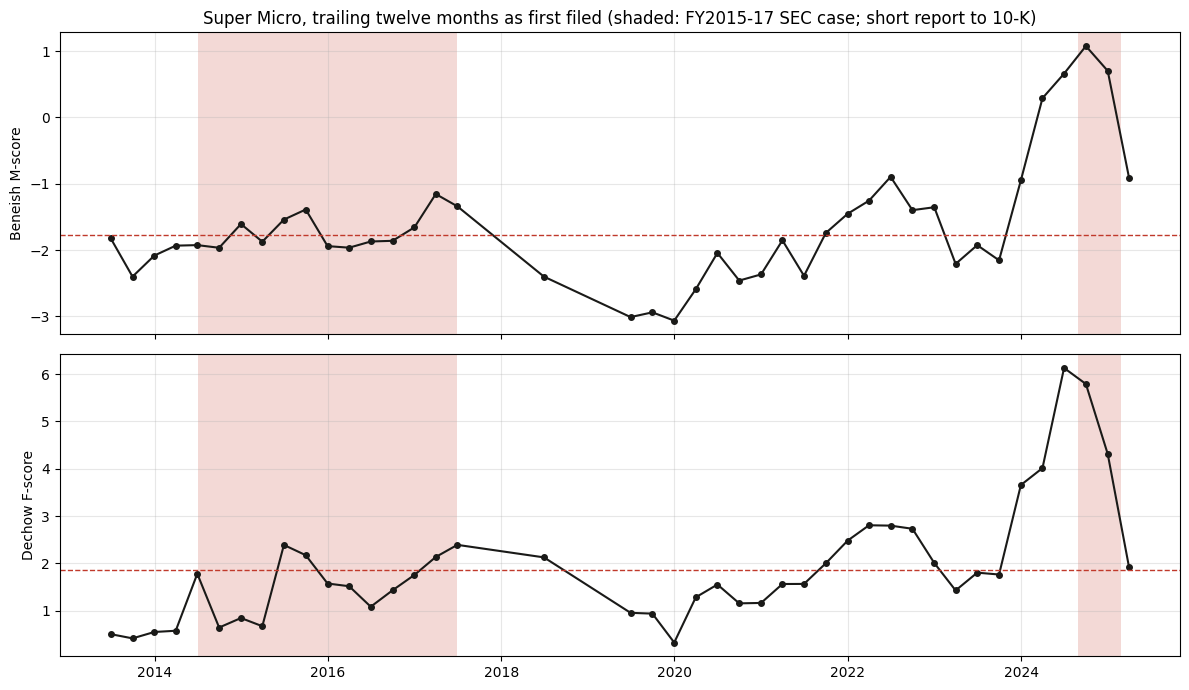

Fiscal 2015 to 2017: M-score above -1.78 in 6 of 12 quarters


In [9]:
tl = TL[TL.complete]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, k, th, lab in [(axes[0], "M", M_THRESHOLD, "Beneish M-score"), (axes[1], "F", 1.85, "Dechow F-score")]:
    ax.axvspan(pd.Timestamp("2014-07-01"), pd.Timestamp("2017-06-30"), color="#f3d9d6", lw=0)
    ax.axvspan(pd.Timestamp("2024-08-27"), pd.Timestamp("2025-02-25"), color="#f3d9d6", lw=0)
    ax.plot(tl.end, tl[k], marker="o", ms=4, color="#1a1a18"); ax.axhline(th, color="#c0392b", ls="--", lw=1)
    ax.set_ylabel(lab); ax.grid(alpha=.3)
axes[0].set_title("Super Micro, trailing twelve months as first filed (shaded: FY2015-17 SEC case; short report to 10-K)")
plt.tight_layout(); plt.show()
epi = tl[(tl.end >= "2014-09-30") & (tl.end <= "2017-06-30")]
print(f"Fiscal 2015 to 2017: M-score above -1.78 in {(epi.M > M_THRESHOLD).sum()} of {len(epi)} quarters")

## 5. What the screen saw on 6 May 2024
The 10-Q for the quarter to 31 March 2024 was filed on 6 May 2024, 113 days before the short report. The waterfall splits
the M-score into what each index adds to a neutral company (every index at 1, no accruals).

In [10]:
snaps = {"pre": snapshot("SMCI", pd.Timestamp("2024-03-31"), first_filed("SMCI", "2024-03-31")),
         "fy24": snapshot("SMCI", pd.Timestamp("2024-06-30"), first_filed("SMCI", "2024-06-30")),
         "now": snapshot("SMCI", pd.Timestamp("2025-03-31"), first_filed("SMCI", "2025-03-31")),
         "fy16": snapshot("SMCI", pd.Timestamp("2015-06-30"), first_filed("SMCI", "2015-06-30"))}
pre = snaps["pre"]
print(f"M-score {pre['M']:+.2f} · F-score {pre['F']:.2f} · sales ${pre['t']['rev'] / 1e9:.2f}bn · net income ${pre['t']['ni'] / 1e9:.2f}bn · "
      f"operating cash flow {pre['t']['cfo'] / 1e9:+.2f} $bn")
pd.DataFrame({"index": pre["b"], "contribution": pre["b_contrib"]}).T

M-score +0.29 · F-score 4.01 · sales $11.82bn · net income $1.05bn · operating cash flow -1.85 $bn


,DSRI,GMI,AQI,SGI,DEPI,SGAI,TATA,LVGI
index,1.366,1.142,0.794,1.798,1.176,0.857,0.327,0.530
contribution,0.336,0.075,-0.083,0.712,0.020,0.025,1.532,0.154


In [11]:
peers = {tk: peer_snap(tk, "2024-03-31", "2024-08-26") for tk in ["NVDA", "DELL", "HPE"]}
cmp_ = pd.DataFrame({k: {"period end": s["end"].date(), "sales growth": s["cash"]["sales_growth"], "receivables growth": s["cash"]["ar_growth"],
                         "CFO / net income": s["cash"]["cfo_ni"], "accruals / assets": s["cash"]["sloan_acc"], "inventory days": s["cash"]["dio"],
                         "M-score": s["M"], "F-score": s["F"], "indices imputed": ",".join(s["M_imputed"])} for k, s in {"SMCI": pre, **peers}.items()})
cmp_

,SMCI,NVDA,DELL,HPE
period end,2024-03-31,2024-04-28,2024-05-03,2024-04-30
sales growth,0.798,2.083,-0.076,-0.044
receivables growth,1.455,2.031,-0.089,0.035
CFO / net income,-1.767,0.951,2.213,3.058
accruals / assets,0.482,0.034,-0.053,-0.065
inventory days,151.571,108.565,25.263,NaN
M-score,0.291,-0.583,-2.820,-2.776
F-score,4.013,0.790,1.464,0.578
indices imputed,,,,GMI


## 6. Every US filer
The same scores for calendar 2023 against 2022 for US operating companies with sales and assets above $50M and complete
data in the SEC frames API. They give the percentiles and the false-alarm rate: how often a clean company is flagged.

1,235 companies · Super Micro (Mar 2024) above 97.6% on M and 99.6% on F
Flagged: M 9.0% · F 4.3% · both 1.7%


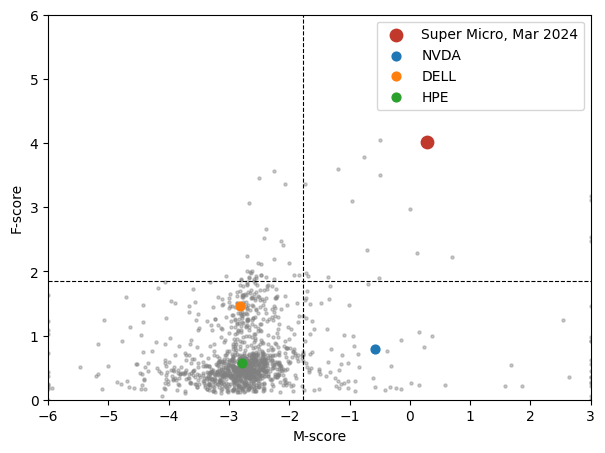

In [12]:
MAP = {'rev': ['Revenues', 'RevenueFromContractWithCustomerExcludingAssessedTax', 'SalesRevenueNet'],
       'cogs': ['CostOfRevenue', 'CostOfGoodsAndServicesSold'], 'gp': ['GrossProfit'], 'sga': ['SellingGeneralAndAdministrativeExpense'],
       'dep': ['DepreciationDepletionAndAmortization', 'DepreciationAndAmortization', 'Depreciation'], 'ni': ['NetIncomeLoss'],
       'cfo': ['NetCashProvidedByUsedInOperatingActivities'], 'iss': ['ProceedsFromIssuanceOfCommonStock', 'ProceedsFromIssuanceOfLongTermDebt'],
       'ar': ['AccountsReceivableNetCurrent'], 'inv': ['InventoryNet'], 'ca': ['AssetsCurrent'], 'ta': ['Assets'], 'ppe': ['PropertyPlantAndEquipmentNet'],
       'cash': ['CashAndCashEquivalentsAtCarryingValue'], 'cl': ['LiabilitiesCurrent'], 'tl': ['Liabilities'], 'ltd': ['LongTermDebtNoncurrent'],
       'sti': ['ShortTermInvestments'], 'lti': ['LongTermInvestments'], 'std': ['DebtCurrent', 'LongTermDebtCurrent']}
W = FR.pivot_table(index=['cik', 'period'], columns='concept', values='val', aggfunc='first')

def rec(cik, y, inst):
    out = {}
    for k, cs in MAP.items():
        per = y + 'Q4I' if k in inst else y
        v = np.nan
        if (cik, per) in W.index:
            row = W.loc[(cik, per)]
            if k == 'iss':
                vals = [row.get(c, np.nan) for c in cs]; v = np.nansum(vals) if any(np.isfinite(vals)) else np.nan
            else:
                for c in cs:
                    if c in row and np.isfinite(row[c]): v = row[c]; break
        out[k] = v
    if not np.isfinite(out['cogs']) and np.isfinite(out['gp']) and np.isfinite(out['rev']): out['cogs'] = out['rev'] - out['gp']
    return out

INST = {'ar', 'inv', 'ca', 'ta', 'ppe', 'cash', 'cl', 'tl', 'ltd', 'sti', 'lti', 'std'}
def build():
    ciks = sorted(set(c for c, p in W.index if p == 'CY2023'))
    rows = []
    for c in ciks:
        t, p, pp = rec(c, 'CY2023', INST), rec(c, 'CY2022', INST), rec(c, 'CY2021', INST)
        need = ['rev', 'ar', 'ca', 'ta', 'ppe', 'cl', 'ni', 'cfo', 'cash', 'tl']
        if not all(np.isfinite(t[k]) and np.isfinite(p[k]) for k in need): continue
        if t['rev'] < 50e6 or t['ta'] < 50e6 or p['rev'] <= 0: continue       # operating companies of some size
        m, mi, imp = beneish(t, p)
        ppok = pp if all(np.isfinite(pp[k]) for k in ('ar', 'rev', 'ta', 'ni')) else None
        f, fv, miss = dechow(t, p, ppok)
        if len(imp) > 2 or not np.isfinite(m) or not np.isfinite(f): continue
        rows.append({'cik': c, 'M': m, 'F': f, 'imputed': len(imp), 'sales_growth': t['rev'] / p['rev'] - 1, 'rev': t['rev'],
                     'sloan_acc': (t['ni'] - t['cfo']) / ((t['ta'] + p['ta']) / 2)})
    return pd.DataFrame(rows)

U = build()
print(f"{len(U):,} companies · Super Micro (Mar 2024) above {(U.M < pre['M']).mean():.1%} on M and {(U.F < pre['F']).mean():.1%} on F")
print(f"Flagged: M {(U.M > M_THRESHOLD).mean():.1%} · F {(U.F > 1.85).mean():.1%} · both {((U.M > M_THRESHOLD) & (U.F > 1.85)).mean():.1%}")
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(U.M.clip(-6, 3), U.F.clip(0, 8), s=5, alpha=.4, color="grey")
ax.scatter(pre["M"], pre["F"], s=80, color="#c0392b", label="Super Micro, Mar 2024")
for k, s in peers.items(): ax.scatter(s["M"], s["F"], s=40, label=k)
ax.axvline(M_THRESHOLD, ls="--", color="k", lw=.8); ax.axhline(1.85, ls="--", color="k", lw=.8)
ax.set_xlim(-6, 3); ax.set_ylim(0, 6); ax.set_xlabel("M-score"); ax.set_ylabel("F-score"); ax.legend(); plt.show()

## 7. Back-test on SEC enforcement cases
16 companies the SEC charged, or that restated, for inflated earnings (SEC press releases and orders). Each misstated
fiscal year is scored **as first filed**. Hertz and Diamond Foods lack standard XBRL tags in those years and are excluded.

In [13]:
IT = ['rev', 'cogs', 'sga', 'dep', 'ni', 'cfo', 'iss', 'ar', 'inv', 'ca', 'ta', 'ppe', 'cash', 'sti', 'lti', 'cl', 'tl', 'ltd', 'std']
CASES = [  # ticker, name, misstated fiscal years (year of FY end), FYE month, nature, SEC action
 ('SMCI', 'Super Micro Computer', [2015, 2016, 2017], 6, 'Revenue timing, some expenses', 'SEC 2020, $17.5M'),
 ('MDXG', 'MiMedx', [2013, 2014, 2015, 2016], 12, 'Revenue (distributor side deals)', 'SEC 2019'),
 ('SNCR', 'Synchronoss', [2015, 2016], 12, 'Revenue', 'SEC 2022, $12.5M'),
 ('SCOR', 'comScore', [2014, 2015], 12, 'Revenue (non-cash swaps)', 'SEC 2019, $5M'),
 ('OSIR', 'Osiris Therapeutics', [2014], 12, 'Revenue', 'SEC 2017, $1.5M'),
 ('MX', 'MagnaChip', [2011, 2012, 2013], 12, 'Revenue', 'SEC 2017, $3M'),
 ('OFIX', 'Orthofix', [2011, 2012], 12, 'Revenue (distributors)', 'SEC 2017, $8.25M'),
 ('TEUM', 'Pareteum', [2018], 12, 'Revenue', 'SEC 2021'),
 ('ICON', 'Iconix Brand', [2013, 2014], 12, 'Revenue and impairments', 'SEC 2019, $5.5M'),
 ('GVA', 'Granite Construction', [2017, 2018, 2019], 12, 'Project cost estimates', 'SEC 2022, $12M'),
 ('DMND', 'Diamond Foods', [2010, 2011], 7, 'Costs deferred (walnut payments)', 'SEC 2014, $5M'),
 ('HTZ', 'Hertz Global', [2011, 2012, 2013], 12, 'Reserves and allowances', 'SEC 2018, $16M'),
 ('RRTS', 'Roadrunner Transportation', [2013, 2014, 2015], 12, 'Expenses deferred', 'SEC 2023'),
 ('KHC', 'Kraft Heinz', [2016, 2017], 12, 'Supplier discounts in COGS', 'SEC 2021, $62M'),
 ('CGI', 'Celadon Group', [2016], 6, 'Impairments avoided', 'SEC 2019'),
 ('MBII', 'Marrone Bio', [2013], 12, 'Revenue', 'SEC 2016, $1.75M'),
]

def fy_end(tk, year, month):
    s = R[(R.tk == tk) & R.form.str.startswith('10-K') & R.days.isna() & R.concept.isin(['Assets'])]
    ends = sorted(s.end.unique())
    cand = [e for e in ends if e.year == year and abs(e.month - month) <= 1 or (e.year == year + (1 if month == 12 else 0) and month == 12 and e.month == 1 and e.day <= 7)]
    return cand[0] if cand else None

def run():
    out = []
    for tk, name, years, mo, nature, sec in CASES:
        for i, y in enumerate(years):
            e = fy_end(tk, y, mo)
            if e is None: out.append({'tk': tk, 'name': name, 'fy': y, 'status': 'no FY end'}); continue
            D = R[(R.tk == tk) & (R.end == e) & R.form.str.match(r'10-K$')].filed.min()
            if pd.isna(D): D = first_filed(tk, e)
            x = scores_at(tk, e, D)
            out.append({'tk': tk, 'name': name, 'fy': y, 'first': i == 0, 'end': e.date(), 'filed': D.date(), 'M': x['M'], 'F': x['F'],
                        'sloan_acc': x['sloan_acc'], 'sales_growth': x['sales_growth'], 'imp': ','.join(x['M_imputed']), 'fmiss': ','.join(x['F_missing']),
                        'nature': nature, 'sec': sec, **{'t_' + k: x['t'][k] for k in IT}, **{'p_' + k: x['p'][k] for k in IT}, **{'pp_' + k: x['pp'][k] for k in ['ar', 'rev', 'ta', 'ni']}})
    return pd.DataFrame(out)

V = run()
V["imp_n"] = V.imp.fillna("").apply(lambda s: len([x for x in str(s).split(",") if x])); V["usable"] = V.M.notna() & (V.imp_n <= 2)
v = V[V.usable]
F_FLAG = 1.85
RULES = [("M-score above -1.78", lambda d: d.M > M_THRESHOLD), ("F-score above 1.85", lambda d: d.F > F_FLAG),
         ("Either flag", lambda d: (d.M > M_THRESHOLD) | (d.F > F_FLAG)), ("Both flags", lambda d: (d.M > M_THRESHOLD) & (d.F > F_FLAG))]
rules = []
for n, f in RULES:
    hy = f(v); cases = v.assign(h=hy).groupby("tk").h.any(); fa = f(U).mean()
    rules.append({"rule": n, "case_years": int(hy.sum()), "n_years": int(len(v)), "hit": hy.mean(), "cases": int(cases.sum()), "n_cases": int(len(cases)),
                  "false_alarm": fa, "lift": hy.mean() / fa})
display(pd.DataFrame(rules))
V[["tk", "name", "fy", "filed", "M", "F", "usable", "nature", "sec"]]

,rule,case_years,n_years,hit,cases,n_cases,false_alarm,lift
0,M-score above -1.78,10,29,0.345,8,14,0.090,3.837
1,F-score above 1.85,6,29,0.207,4,14,0.043,4.821
2,Either flag,12,29,0.414,9,14,0.116,3.574
3,Both flags,4,29,0.138,3,14,0.017,8.112


,tk,name,fy,filed,M,F,usable,nature,sec
0,SMCI,Super Micro Computer,2015,2015-09-10,-1.540,2.389,True,"Revenue timing, some expenses","SEC 2020, $17.5M"
1,SMCI,Super Micro Computer,2016,2016-08-26,-1.871,1.083,True,"Revenue timing, some expenses","SEC 2020, $17.5M"
2,SMCI,Super Micro Computer,2017,2019-05-17,-1.340,2.391,True,"Revenue timing, some expenses","SEC 2020, $17.5M"
3,MDXG,MiMedx,2013,2014-03-04,-1.622,1.273,True,Revenue (distributor side deals),SEC 2019
4,MDXG,MiMedx,2014,2015-03-13,-2.445,0.453,True,Revenue (distributor side deals),SEC 2019
5,MDXG,MiMedx,2015,2016-02-29,-1.235,0.873,True,Revenue (distributor side deals),SEC 2019
6,MDXG,MiMedx,2016,2017-03-01,-2.607,0.813,True,Revenue (distributor side deals),SEC 2019
7,SNCR,Synchronoss,2015,2016-02-26,-2.393,0.454,True,Revenue,"SEC 2022, $12.5M"
8,SNCR,Synchronoss,2016,2017-02-27,-3.444,0.444,True,Revenue,"SEC 2022, $12.5M"
9,SCOR,comScore,2014,2015-02-20,-3.266,0.507,True,Revenue (non-cash swaps),"SEC 2019, $5M"


## 8. The market
Split-adjusted closes. Abnormal return = Super Micro's return minus beta times the Nasdaq-100 (QQQ) return, with beta
estimated from July 2023 to July 2024, before the events.

In [14]:
PXR, beta, EV, MK = market()
print(f"Beta {beta:.2f} · 10-Q (6 May 2024) to the low (14 Nov 2024): {MK['drop_from_screen_to_low']:.1%}, QQQ {MK['qqq_same']:+.1%}")
pd.DataFrame(EV)[["date", "title", "close", "ret", "ar"]]

Beta 3.00 · 10-Q (6 May 2024) to the low (14 Nov 2024): -78.3%, QQQ +15.5%


,date,title,close,ret,ar
0,2024-03-13,Record close,118.807,0.022,0.045
1,2024-05-06,Q3 FY24 10-Q,83.035,0.061,0.028
2,2024-08-07,Q4 results,49.270,-0.201,-0.169
3,2024-08-27,Hindenburg,54.764,-0.026,-0.035
4,2024-08-28,10-K delayed,44.349,-0.190,-0.156
5,2024-09-26,DOJ probe,40.240,-0.122,-0.144
6,2024-10-30,EY resigns,33.070,-0.327,-0.304
7,2024-11-19,BDO hired,28.270,0.312,0.292
8,2024-12-02,Committee report,42.000,0.287,0.254
9,2025-02-26,10-K filed,51.110,0.122,0.115


## 9. June 2025 and the red flags outside the ratios
The audited fiscal 2024 10-K (25 February 2025) and the latest 10-Q (12 May 2025), next to the pre-report reading. The
filing history gives two flags a screen cannot compute: late-filing notices and changes of auditor (8-K item 4.01).

In [15]:
now_tbl = pd.DataFrame({k: {"sales $bn": s["t"]["rev"] / 1e9, "net income $bn": s["t"]["ni"] / 1e9, "CFO $bn": s["t"]["cfo"] / 1e9,
                            "inventory days": s["cash"]["dio"], "accruals / assets": s["cash"]["sloan_acc"], "M-score": s["M"], "F-score": s["F"]}
                        for k, s in [("6 May 2024", snaps["pre"]), ("FY2024 10-K", snaps["fy24"]), ("12 May 2025", snaps["now"])]})
display(now_tbl)
nt = FILINGS[FILINGS.form.str.startswith("NT 10-K")]
aud = FILINGS[FILINGS["items"].str.contains("4.01")]
print("Late 10-K notices:", ", ".join(nt.filed.str[:4].unique()))
print("Auditor-change 8-Ks (item 4.01):", ", ".join(aud.filed.tolist()))

,6 May 2024,FY2024 10-K,12 May 2025
sales $bn,11.820,14.989,21.570
net income $bn,1.049,1.153,1.151
CFO $bn,-1.853,-2.486,0.148
inventory days,151.571,122.337,73.814
accruals / assets,0.482,0.539,0.102
M-score,0.291,0.662,-0.912
F-score,4.013,6.129,1.914


Late 10-K notices: 2024, 2019, 2018, 2017, 2015
Auditor-change 8-Ks (item 4.01): 2024-11-18, 2024-10-30, 2023-03-15


The page template (HTML, CSS and JavaScript) is kept in the notebook so the project runs from a single file.
The page loads Plotly and the fonts from public CDNs.

In [16]:
PAGE_TEMPLATE = r'''<meta charset="utf-8">
<title>Super Micro Forensic Analysis</title>
<meta name="author" content="Alessandro Radice">
<meta name="description" content="Forensic accounting screen on Super Micro Computer (June 2025): Beneish M-score, Dechow F-score and cash conversion rebuilt point in time from SEC XBRL filings, the view before the August 2024 short report, a back-test on 14 SEC enforcement cases, and the position after the February 2025 filings.">
<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=Instrument+Serif:ital@0;1&family=IBM+Plex+Sans:wght@400;500;600&family=IBM+Plex+Mono:wght@400;500&display=swap">
<script src="https://cdn.jsdelivr.net/npm/plotly.js-dist-min@2.35.2/plotly.min.js"></script>
<style>
  /* One deliberate dark look, like a diligence team's screen. Every colour is painted explicitly. */
  :root {
    color-scheme: dark;
    --ground: #101112;
    --panel: #17181b;
    --panel-2: #1e2024;
    --rule: #2b2d32;
    --rule-strong: #3d4047;
    --text: #edeae3;
    --text-2: #bab7ae;
    --muted: #8f8c85;
    --acc: #e7b04c;
    --acc-soft: rgba(231, 176, 76, .10);
    --flag: #e2665c;
    --flag-soft: rgba(226, 102, 92, .10);
    --clean: #5fb88a;
    --alt: #9aa7b8;
    --alt2: #c9c5bb;
    --serif: "Instrument Serif", "Iowan Old Style", "Palatino Linotype", Georgia, serif;
    --sans: "IBM Plex Sans", -apple-system, "Segoe UI", Roboto, sans-serif;
    --mono: "IBM Plex Mono", ui-monospace, "SFMono-Regular", Menlo, Consolas, monospace;
  }
  * { box-sizing: border-box; }
  html { background: var(--ground); }
  body { background: var(--ground); color: var(--text); font-family: var(--sans); font-size: 15px; line-height: 1.55; margin: 0; }
  .wrap { max-width: 1280px; margin: 0 auto; padding-inline: 24px; padding-block: 32px 64px; }
  @media (max-width: 640px) { .wrap { padding-inline: 16px; padding-block: 20px 48px; } }

  .eyebrow { font-family: var(--mono); font-size: 12px; letter-spacing: .08em; text-transform: uppercase; color: var(--muted); }
  h1 { font-family: var(--serif); font-weight: 400; font-size: clamp(40px, 6vw, 72px); line-height: 1.02; margin: 10px 0 14px; text-wrap: balance; letter-spacing: -.01em; }
  h1 em { color: var(--acc); font-style: italic; }
  .h1sub { display: block; font-size: 0.56em; line-height: 1.15; margin-top: 6px; color: var(--text-2); }
  .dek { font-size: 17px; color: var(--text-2); max-width: 68ch; margin: 0; }
  .masthead { display: grid; grid-template-columns: minmax(0, 1.35fr) minmax(0, 1fr); gap: 40px; align-items: end; padding-bottom: 28px; border-bottom: 1px solid var(--rule); }
  .brief { border-left: 2px solid var(--acc); padding: 4px 0 4px 18px; }
  .brief .label { font-family: var(--mono); font-size: 11px; letter-spacing: .1em; text-transform: uppercase; color: var(--acc); margin-bottom: 6px; }
  .brief p { margin: 0; font-family: var(--serif); font-size: 22px; line-height: 1.3; color: var(--text); }
  @media (max-width: 900px) { .masthead { grid-template-columns: 1fr; gap: 20px; } }

  .findings { display: grid; grid-template-columns: repeat(4, minmax(0, 1fr)); border-bottom: 1px solid var(--rule); }
  .finding { padding: 18px 20px 18px 0; }
  .finding + .finding { padding-left: 20px; border-left: 1px solid var(--rule); }
  .finding .v { font-family: var(--mono); font-size: 26px; font-weight: 500; font-variant-numeric: tabular-nums; color: var(--text); white-space: nowrap; }
  .finding .v.flag { color: var(--flag); }
  .finding .k { font-size: 13px; color: var(--muted); margin-top: 2px; }
  @media (max-width: 900px) { .findings { grid-template-columns: repeat(2, minmax(0, 1fr)); } .finding:nth-child(3) { border-left: 0; padding-left: 0; } .finding:nth-child(n+3) { border-top: 1px solid var(--rule); } }
  @media (max-width: 640px) { .finding .v { font-size: 18px; } .finding { padding-right: 10px; } .finding + .finding { padding-left: 10px; } }

  section { margin-top: 44px; }
  h2 { font-family: var(--serif); font-weight: 400; font-size: clamp(28px, 3.6vw, 40px); line-height: 1.1; margin: 0 0 8px; text-wrap: balance; }
  h3 { font: 600 13px var(--sans); letter-spacing: .06em; text-transform: uppercase; color: var(--text-2); margin: 0 0 2px; }
  .sub { font-size: 13px; color: var(--muted); margin: 0 0 8px; }
  .lead { color: var(--text-2); max-width: 74ch; margin: 0 0 18px; }
  .lead b { color: var(--text); font-weight: 600; }
  .panel { background: var(--panel); border: 1px solid var(--rule); border-radius: 10px; padding: 16px 16px 8px; min-width: 0; }
  .grid2 { display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 16px; margin-top: 16px; }
  .grid-wide { display: grid; grid-template-columns: minmax(0, 1.5fr) minmax(0, 1fr); gap: 16px; margin-top: 16px; }
  @media (max-width: 1000px) { .grid2, .grid-wide { grid-template-columns: 1fr; } }
  .chart { height: 330px; }
  #tl { height: 380px; } #uni { height: 420px; } #px { height: 360px; } #mwf { height: 330px; }
  @media (max-width: 640px) { #tl { height: 320px; } #uni { height: 360px; } }

  .seg { display: inline-flex; flex-wrap: wrap; gap: 6px; margin: 4px 0 10px; }
  .seg button { font: 500 12px var(--mono); color: var(--text-2); background: transparent; border: 1px solid var(--rule-strong); border-radius: 999px; padding: 4px 11px; cursor: pointer; }
  .seg button:hover { color: var(--text); border-color: var(--muted); }
  .seg button.on { color: var(--ground); background: var(--acc); border-color: var(--acc); }
  .seg button:focus-visible, input[type=range]:focus-visible { outline: 2px solid var(--acc); outline-offset: 2px; }
  .explain { font-size: 13px; color: var(--text-2); min-height: 40px; margin: 0 0 6px; max-width: 90ch; }

  .tablewrap { overflow-x: auto; margin-top: 12px; }
  table { border-collapse: collapse; width: 100%; font-size: 14px; }
  th, td { padding: 9px 12px; text-align: right; border-bottom: 1px solid var(--rule); white-space: nowrap; font-variant-numeric: tabular-nums; }
  th { font: 500 12px var(--sans); color: var(--muted); letter-spacing: .03em; border-bottom-color: var(--rule-strong); vertical-align: bottom; }
  td { font-family: var(--mono); font-size: 13.5px; }
  th:first-child, td:first-child { text-align: left; font-family: var(--sans); }
  td.l, th.l { text-align: left; font-family: var(--sans); white-space: normal; min-width: 240px; }
  tr.focus td { background: var(--acc-soft); }
  .flag { color: var(--flag); } .clean { color: var(--clean); } .dim { color: var(--muted); }
  .dot { display: inline-block; width: 8px; height: 8px; border-radius: 50%; margin-right: 6px; vertical-align: 1px; }

  .sliders { display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 8px 28px; padding: 6px 2px 4px; }
  .sl { display: flex; align-items: center; gap: 12px; }
  .sl label { font: 500 13px var(--sans); color: var(--text-2); white-space: nowrap; }
  .sl output { font: 500 16px var(--mono); min-width: 6ch; font-variant-numeric: tabular-nums; }
  input[type=range] { flex: 1 1 200px; accent-color: var(--acc); min-width: 0; }
  @media (max-width: 700px) { .sliders { grid-template-columns: 1fr; } }

  .checks { list-style: none; margin: 14px 0 0; padding: 0; display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 0 28px; }
  .checks li { display: grid; grid-template-columns: 22px 1fr; gap: 8px; padding: 10px 0; border-top: 1px solid var(--rule); font-size: 14px; color: var(--text-2); }
  .checks li b { color: var(--text); font-weight: 600; }
  .checks .mk { font: 600 13px var(--mono); }
  @media (max-width: 900px) { .checks { grid-template-columns: 1fr; } }

  .events { list-style: none; margin: 14px 0 0; padding: 0; display: grid; grid-template-columns: repeat(auto-fill, minmax(240px, 1fr)); gap: 10px 22px; }
  .events li { font-size: 13px; color: var(--text-2); border-top: 1px solid var(--rule); padding-top: 8px; }
  .events li b { display: block; font: 500 12px var(--mono); color: var(--acc); letter-spacing: .03em; }

  .verdict { display: grid; grid-template-columns: minmax(0, 1fr) minmax(0, 1fr); gap: 32px; margin-top: 20px; }
  .verdict p { margin: 0 0 12px; color: var(--text-2); }
  .verdict p strong { color: var(--text); font-weight: 600; }
  .verdict .call { font-family: var(--serif); font-size: 26px; line-height: 1.25; color: var(--text); margin: 0 0 12px; }
  @media (max-width: 900px) { .verdict { grid-template-columns: 1fr; gap: 8px; } }

  .method { display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 12px 40px; counter-reset: step; margin: 16px 0 0; padding: 0; list-style: none; }
  .method li { counter-increment: step; position: relative; padding-left: 36px; color: var(--text-2); font-size: 14px; }
  .method li::before { content: counter(step, decimal-leading-zero); position: absolute; left: 0; top: 1px; font: 12px var(--mono); color: var(--acc); }
  .method li b { color: var(--text); font-weight: 600; }
  @media (max-width: 900px) { .method { grid-template-columns: 1fr; } }
  .notes { color: var(--muted); font-size: 13.5px; max-width: 90ch; }
  .notes li { margin-bottom: 6px; }
  .sources { columns: 2; column-gap: 40px; font-size: 13px; color: var(--muted); padding-left: 18px; }
  .sources li { margin-bottom: 6px; break-inside: avoid; }
  @media (max-width: 800px) { .sources { columns: 1; } }
  a { color: var(--acc); text-underline-offset: 2px; }
  .formula { font-family: var(--mono); font-size: 13.5px; line-height: 1.6; color: var(--text); background: var(--panel-2); border: 1px solid var(--rule); border-radius: 8px; padding: 10px 14px; margin: 10px 0 0; }
  footer { margin-top: 48px; padding-top: 16px; border-top: 1px solid var(--rule); display: flex; justify-content: space-between; gap: 16px; flex-wrap: wrap; font-size: 13px; color: var(--muted); }
</style>

<div class="wrap">
  <header class="masthead">
    <div>
      <div class="eyebrow">Forensic due diligence &middot; June 2025</div>
      <h1>Super Micro Forensic Analysis<span class="h1sub">Earnings quality and <em>accounting red flags</em></span></h1>
      <p class="dek">Super Micro Computer went from one of the market's best performers in early 2024 to a short report, a delayed 10-K and an auditor's resignation within months. This page rebuilds its financial statements from SEC filings exactly as they were published, runs two standard manipulation screens on every quarter since 2013, tests the screens on 14 companies the SEC later charged, and reads the numbers as they stand after the February 2025 filings.</p>
    </div>
    <div class="brief">
      <div class="label">The question &middot; 30 June 2025, credit committee</div>
      <p>Super Micro's audited accounts are back, with a clean opinion on the numbers and an adverse one on internal controls. Do the statements themselves carry red flags, would a screen have seen the trouble first, and how far can it be trusted?</p>
    </div>
  </header>

  <div class="findings" id="findings"></div>

  <section>
    <h2>Twelve years through a forensic lens</h2>
    <p class="lead" id="tl-lead"></p>
    <div class="panel">
      <div class="seg" id="tl-seg"></div>
      <p class="explain" id="tl-explain"></p>
      <div id="tl"></div>
    </div>
  </section>

  <section>
    <h2>What the screen saw on 6 May 2024</h2>
    <p class="lead" id="pre-lead"></p>
    <div class="grid2">
      <div class="panel"><h3>Beneish M-score, index by index</h3><p class="sub" id="mwf-sub"></p><div class="seg" id="mwf-seg"></div><div id="mwf"></div></div>
      <div class="panel"><h3>Against every US filer and the AI hardware peers</h3><p class="sub">M-score and F-score for 2023 against 2022, 1,235 US operating companies with complete XBRL data (axes clipped); peers at their quarter nearest March 2024</p><div id="uni"></div></div>
    </div>
    <div class="tablewrap"><table id="pre-table"></table></div>
  </section>

  <section>
    <h2>Then the market caught up</h2>
    <p class="lead" id="px-lead"></p>
    <div class="panel"><h3>Super Micro share price</h3><p class="sub">Daily close, split-adjusted (10-for-1 on 1 October 2024), log scale; amber = the screen, red = market events</p><div id="px"></div></div>
    <div class="tablewrap"><table id="ev-table"></table></div>
  </section>

  <section>
    <h2>Would it have worked before?</h2>
    <p class="lead" id="val-lead"></p>
    <div class="panel">
      <h3>Hit rate against false alarms</h3>
      <p class="sub">Move the thresholds: share of misstated years flagged (as first filed) against the share of all 2023 filers flagged</p>
      <div class="sliders">
        <div class="sl"><label for="thM">M-score above</label><input type="range" id="thM" min="-3" max="0" step="0.01" value="-1.78"><output id="thMo"></output></div>
        <div class="sl"><label for="thF">F-score above</label><input type="range" id="thF" min="0.5" max="4" step="0.05" value="1.85"><output id="thFo"></output></div>
      </div>
      <div class="tablewrap"><table id="rule-table"></table></div>
    </div>
    <div class="tablewrap"><table id="case-table"></table></div>
  </section>

  <section>
    <h2>Where it stands in June 2025</h2>
    <p class="lead" id="now-lead"></p>
    <div class="tablewrap"><table id="now-table"></table></div>
    <h3 style="margin-top:26px">Red flags outside the ratios</h3>
    <ul class="checks" id="checks"></ul>
  </section>

  <section>
    <h2>The call</h2>
    <div class="verdict">
      <div><p class="call" id="call"></p></div>
      <div id="verdict"></div>
    </div>
  </section>

  <section>
    <h2>Method</h2>
    <ol class="method" id="method"></ol>
    <div class="formula">M = −4.84 + 0.920·DSRI + 0.528·GMI + 0.404·AQI + 0.892·SGI + 0.115·DEPI − 0.172·SGAI + 4.679·TATA − 0.327·LVGI</div>
    <div class="formula">F = P(misstatement) / 0.0037, &nbsp; logit P = −7.893 + 0.790·RSST accruals + 2.518·ΔReceivables + 1.191·ΔInventory + 1.979·Soft assets + 0.171·ΔCash sales − 0.932·ΔROA + 1.029·Issuance</div>
    <h3 style="margin-top:22px">Limitations</h3>
    <ul class="notes" id="limits"></ul>
    <h3 style="margin-top:22px">Data and sources</h3>
    <ul class="sources">
      <li>Financial statements: SEC EDGAR XBRL company facts and frames APIs (data.sec.gov), every value kept with the date it was filed</li>
      <li>Filing history (10-K, 10-Q, NT filings, 8-K items): SEC EDGAR submissions API</li>
      <li>Share prices: post-no-preference/stocks, DoltHub; split-adjusted here</li>
      <li><a href="https://www.sec.gov/newsroom/press-releases/2020-190">SEC charges Super Micro Computer with widespread accounting violations</a>, SEC press release 2020-190 (25 August 2020)</li>
      <li><a href="https://www.sec.gov/Archives/edgar/data/0001375365/000137536524000036/smci-20241024.htm">Form 8-K, change in certifying accountant (EY resignation)</a>, Super Micro (30 October 2024)</li>
      <li><a href="https://www.sec.gov/Archives/edgar/data/1375365/000137536524000044/pressrelease-specialcommit.htm">Special committee findings</a>, Super Micro (2 December 2024)</li>
      <li><a href="https://www.sec.gov/Archives/edgar/data/1375365/000137536525000004/smci-20240630.htm">Form 10-K for fiscal 2024</a>, Super Micro (25 February 2025)</li>
      <li><a href="https://hindenburgresearch.com/smci/">Super Micro: Fresh evidence of accounting manipulation</a>, Hindenburg Research (27 August 2024)</li>
      <li>SEC press releases 2016-32, 2017-18, 2017-207, 2019-60, 2019-186, 2019-243, 2019-251, 2021-174, 2022-101, 2022-150 and orders 33-10352, 33-10601, 33-10975, 33-11156 (validation cases)</li>
      <li>Beneish, M. D. (1999), The detection of earnings manipulation, Financial Analysts Journal 55(5)</li>
      <li>Dechow, Ge, Larson and Sloan (2011), Predicting material accounting misstatements, Contemporary Accounting Research 28(1)</li>
      <li>Richardson, Sloan, Soliman and Tuna (2005), Accrual reliability, earnings persistence and stock prices, Journal of Accounting and Economics 39(3)</li>
    </ul>
  </section>

  <footer>
    <span>Alessandro Radice &middot; M.Sc. Economics and Business Law (Finance), Università Cattolica del Sacro Cuore</span>
    <span>Educational research project. Not investment advice.</span>
  </footer>
</div>

<script>
const D = __DATA__;
const C = { text: '#edeae3', text2: '#bab7ae', muted: '#8f8c85', rule: '#2b2d32', panel: '#17181b', acc: '#e7b04c', flag: '#e2665c', clean: '#5fb88a', alt: '#9aa7b8', alt2: '#c9c5bb' };
const cfg = { displayModeBar: false, responsive: true };
const MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'];
const fd = s => { const [y, m, d] = s.split('-'); return `${+d} ${MONTHS[+m - 1]} ${y}`; };
const fdm = s => { const [y, m] = s.split('-'); return `${MONTHS[+m - 1]} ${y}`; };
const pct = (x, d = 0) => (x * 100).toFixed(d) + '%';
const sg = (x, d = 2) => (x >= 0 ? '+' : '−') + Math.abs(x).toFixed(d);
const bn = x => '$' + (x / 1e9).toFixed(2) + 'bn';
const bnS = x => (x < 0 ? '−$' : '$') + Math.abs(x / 1e9).toFixed(2) + 'bn';
const ax = o => Object.assign({ gridcolor: C.rule, zerolinecolor: C.rule, linecolor: C.rule, tickfont: { family: 'IBM Plex Mono', size: 11, color: C.muted }, title: { font: { size: 12, color: C.muted } } }, o);
const base = o => Object.assign({ paper_bgcolor: 'rgba(0,0,0,0)', plot_bgcolor: 'rgba(0,0,0,0)', font: { family: 'IBM Plex Sans', color: C.text2, size: 12 }, margin: { l: 56, r: 16, t: 10, b: 44 }, showlegend: false, hoverlabel: { bgcolor: '#1e2024', bordercolor: C.rule, font: { family: 'IBM Plex Mono', color: C.text, size: 12 } } }, o);
const M0 = D.meta.M_threshold, F0 = D.meta.F_flag;
const S = D.snaps, pre = S.pre, fy24 = S.fy24, now = S.now, U = D.universe, V = D.validation, MK = D.market, T = D.timeline;
const mfmt = x => (x >= 0 ? '+' : '−') + Math.abs(x).toFixed(2);

// ---------- findings ----------
const bestRule = V.rules[2];
document.getElementById('findings').innerHTML = [
  [mfmt(pre.M), 'M-score on 6 May 2024, against a −1.78 threshold', true],
  [pre.F.toFixed(1) + '×', 'F-score: misstatement risk against the average filer', true],
  [pct(MK.drop_from_screen_to_low), 'share price, 10-Q to the November 2024 low (Nasdaq-100 ' + sg(MK.qqq_same * 100, 0) + '%)', false],
  [`${bestRule.cases} of ${bestRule.n_cases}`, `SEC cases flagged, against ${pct(bestRule.false_alarm)} of all filers`, false]
].map(([v, k, f]) => `<div class="finding"><div class="v${f ? ' flag' : ''}">${v}</div><div class="k">${k}</div></div>`).join('');

// ---------- timeline ----------
const idxPre = T.end.indexOf('2024-03-31');
const epi = (() => { let n = 0, tot = 0; T.end.forEach((e, i) => { if (e >= '2014-09-30' && e <= '2017-06-30' && T.complete[i]) { tot++; if (T.M[i] > M0) n++; } }); return { n, tot }; })();
document.getElementById('tl-lead').innerHTML = `Each point is the trailing twelve months at a quarter end, rebuilt only from filings made by the day that quarter's 10-Q or 10-K came out, so every number is the one an analyst could have read then. The screen lit up twice. In <b>fiscal 2015 to 2017</b>, the years the SEC later found misstated, the M-score sat above the −1.78 line in ${epi.n} of ${epi.tot} quarters. In <b>early 2024</b> it went further than ever: by the 10-Q of 6 May 2024 the M-score was ${mfmt(pre.M)} and the F-score ${pre.F.toFixed(1)}, both far into the red zone, three and a half months before the short report. It also flagged fiscal 2022, when nothing was later restated: a red flag is a question, not a verdict.`;
const METRICS = {
  M: { label: 'M-score', key: 'M', th: M0, thl: 'manipulation threshold −1.78', fmt: x => mfmt(x), note: 'Beneish (1999): eight indices of receivables, margins, asset quality, growth, depreciation, overheads, accruals and leverage. Above −1.78 the profile looks like the manipulators in his sample.' },
  F: { label: 'F-score', key: 'F', th: F0, thl: 'substantial risk 1.85', fmt: x => x.toFixed(2), note: 'Dechow, Ge, Larson and Sloan (2011): probability of a material misstatement relative to the 0.37% base rate. Above 1.85 is "substantial" risk, above 2.45 "high".' },
  acc: { label: 'Accruals', key: 'sloan_acc', th: 0.10, thl: 'accruals above 10% of assets', fmt: x => pct(x, 1), note: 'Net income minus operating cash flow, over average total assets. Profits that do not turn into cash are the common thread in most manipulation cases.' },
  cc: { label: 'Cash conversion', key: 'cfo_ni', th: 0, thl: 'operating cash flow below zero', fmt: x => x.toFixed(2) + '×', note: 'Operating cash flow divided by net income. Below zero means the business reported a profit while burning cash.' },
  dso: { label: 'Receivable days', key: 'dso', th: null, fmt: x => x.toFixed(0) + ' days', note: 'Receivables at the quarter end over trailing sales, times 365. A jump can mean sales booked before customers are committed to pay.' },
  dio: { label: 'Inventory days', key: 'dio', th: null, fmt: x => x.toFixed(0) + ' days', note: 'Inventory over trailing cost of sales, times 365. Stock piling up faster than sales is the second balance-sheet warning in the F-score.' }
};
const segTL = document.getElementById('tl-seg');
segTL.innerHTML = Object.entries(METRICS).map(([k, m]) => `<button data-k="${k}" class="${k === 'M' ? 'on' : ''}">${m.label}</button>`).join('');
function drawTL(k) {
  const m = METRICS[k]; document.getElementById('tl-explain').textContent = m.note;
  const xs = [], ys = [], tx = [], col = [];
  let last = null;
  T.end.forEach((e, i) => {
    if (!T.complete[i]) return; const y = T[m.key][i]; if (y === null) return;
    if (last && (new Date(e) - new Date(last)) / 864e5 > 200) { xs.push(null); ys.push(null); col.push(C.acc); tx.push(''); }
    last = e; xs.push(e); ys.push(y);
    const bad = m.th === null ? false : (k === 'cc' ? y < m.th : y > m.th);
    col.push(bad ? C.flag : C.acc);
    tx.push(`TTM to ${fd(e)}<br>filed ${fd(T.filed[i])}${T.restated_filing[i] ? ' (late)' : ''}<br>${m.label} ${m.fmt(y)}`);
  });
  const shapes = [{ type: 'rect', xref: 'x', yref: 'paper', x0: '2014-07-01', x1: '2017-06-30', y0: 0, y1: 1, fillcolor: 'rgba(226,102,92,.08)', line: { width: 0 } },
                  { type: 'rect', xref: 'x', yref: 'paper', x0: '2024-08-27', x1: '2025-02-25', y0: 0, y1: 1, fillcolor: 'rgba(226,102,92,.08)', line: { width: 0 } }];
  if (m.th !== null) shapes.push({ type: 'line', xref: 'paper', x0: 0, x1: 1, y0: m.th, y1: m.th, line: { color: C.flag, width: 1, dash: 'dot' } });
  const ann = [{ x: '2016-01-01', y: 1, yref: 'paper', text: 'FY2015–17: SEC case', showarrow: false, yanchor: 'top', font: { size: 11, color: C.flag } },
               { x: '2024-11-10', y: 1, yref: 'paper', text: 'short report → 10-K', showarrow: false, yanchor: 'top', font: { size: 11, color: C.flag } }];
  if (m.th !== null) ann.push({ x: '2013-08-01', y: m.th, text: m.thl, showarrow: false, xanchor: 'left', yanchor: 'bottom', font: { size: 11, color: C.flag } });
  Plotly.react('tl', [{ x: xs, y: ys, mode: 'lines+markers', line: { color: C.acc, width: 1.6 }, marker: { size: 7, color: col, line: { color: '#101112', width: 1 } }, text: tx, hovertemplate: '%{text}<extra></extra>' }],
    base({ xaxis: ax({ type: 'date', range: ['2013-06-01', '2025-06-30'] }), yaxis: ax({ title: { text: m.label }, zeroline: false }), shapes, annotations: ann }), cfg);
}
segTL.addEventListener('click', e => { const b = e.target.closest('button'); if (!b) return; segTL.querySelectorAll('button').forEach(x => x.classList.toggle('on', x === b)); drawTL(b.dataset.k); });
drawTL('M');

// ---------- what the screen saw ----------
const cashPre = pre.cash;
document.getElementById('pre-lead').innerHTML = `In the twelve months to 31 March 2024 Super Micro reported <b>${bn(pre.t.rev)} of sales and ${bn(pre.t.ni)} of net income, but ${bnS(pre.t.cfo)} of operating cash flow</b>. Receivables grew ${pct(cashPre.ar_growth)} against sales growth of ${pct(cashPre.sales_growth)}, and inventory reached ${bn(pre.t.inv)} (${cashPre.dio.toFixed(0)} days of cost of sales, from ${cashPre.dio_prev.toFixed(0)}). Growth alone moves the M-score: Nvidia, growing faster still, also crosses −1.78. What separates Super Micro is <b>accruals</b>: profit not turning into cash contributes ${sg(pre.b_contrib.TATA)} to its M-score, and receivables, inventory and soft assets drive an F-score of ${pre.F.toFixed(1)}. It sat above ${pct(U.pct_M, 1)} of US filers on M and ${pct(U.pct_F, 1)} on F; only ${pct(U.share_both, 1)} of companies carried both flags.`;
const BLAB = { DSRI: 'Receivables vs sales', GMI: 'Gross margin decline', AQI: 'Asset quality', SGI: 'Sales growth', DEPI: 'Depreciation rate', SGAI: 'SG&A intensity', TATA: 'Accruals (NI − CFO)', LVGI: 'Leverage' };
const segW = document.getElementById('mwf-seg');
const WSNAP = { pre: ['6 May 2024 (TTM Mar 24)', pre], fy24: ['FY2024 10-K', fy24], now: ['12 May 2025 (TTM Mar 25)', now], fy16: ['FY2015 10-K', S.fy16] };
segW.innerHTML = Object.entries(WSNAP).map(([k, [l]]) => `<button data-k="${k}" class="${k === 'pre' ? 'on' : ''}">${l}</button>`).join('');
function drawW(k) {
  const s = WSNAP[k][1]; const order = ['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'TATA', 'LVGI'];
  document.getElementById('mwf-sub').textContent = `From a neutral company (every index at 1, no accruals: M = ${mfmt(D.meta.M_neutral)}) to ${mfmt(s.M)}; bars show what each index adds`;
  const x = ['Neutral', ...order.map(o => BLAB[o]), 'M-score'];
  const meas = ['absolute', ...order.map(() => 'relative'), 'total'];
  const y = [D.meta.M_neutral, ...order.map(o => s.b_contrib[o]), 0];
  const txt = [mfmt(D.meta.M_neutral), ...order.map(o => sg(s.b_contrib[o])), mfmt(s.M)];
  Plotly.react('mwf', [{ type: 'waterfall', x, y, measure: meas, text: txt, textposition: 'outside', textfont: { family: 'IBM Plex Mono', size: 10.5, color: C.text2 }, cliponaxis: false,
    increasing: { marker: { color: C.flag } }, decreasing: { marker: { color: C.clean } }, totals: { marker: { color: C.acc } }, connector: { line: { color: C.rule } },
    hovertemplate: '%{x}: %{text}<extra></extra>' }],
    base({ margin: { l: 44, r: 10, t: 24, b: 96 }, xaxis: ax({ tickangle: -35, tickfont: { family: 'IBM Plex Sans', size: 10.5, color: C.muted } }), yaxis: ax({ zeroline: false, range: [-3.2, Math.max(0.6, s.M + 0.8, D.meta.M_neutral + Math.max(...order.map(o => s.b_contrib[o])) + 0.6)] }),
      shapes: [{ type: 'line', xref: 'paper', x0: 0, x1: 1, y0: M0, y1: M0, line: { color: C.flag, width: 1, dash: 'dot' } }] }), cfg);
}
segW.addEventListener('click', e => { const b = e.target.closest('button'); if (!b) return; segW.querySelectorAll('button').forEach(x => x.classList.toggle('on', x === b)); drawW(b.dataset.k); });
drawW('pre');

const peers = D.peers; const PC = { NVDA: C.clean, DELL: C.alt, HPE: C.alt2 };
Plotly.newPlot('uni', [
  { x: U.M, y: U.F, mode: 'markers', marker: { size: 4, color: 'rgba(186,183,174,.28)' }, hovertemplate: 'M %{x:.2f} · F %{y:.2f}<extra>US filer, 2023</extra>' },
  ...Object.entries(peers).map(([k, p]) => ({ x: [p.M], y: [p.F], mode: 'markers+text', text: [k], textposition: 'top center', textfont: { family: 'IBM Plex Mono', size: 11, color: PC[k] }, marker: { size: 10, color: PC[k], line: { color: '#101112', width: 1 } }, hovertemplate: `${k} · TTM to ${fd(p.end)}<br>M %{x:.2f} · F %{y:.2f}<extra></extra>` })),
  { x: [pre.M], y: [Math.min(pre.F, 8)], mode: 'markers+text', text: ['SMCI'], textposition: 'top left', textfont: { family: 'IBM Plex Mono', size: 12, color: C.flag }, marker: { size: 13, color: C.flag, line: { color: '#101112', width: 1.5 } }, hovertemplate: `Super Micro · TTM to 31 Mar 2024<br>M ${mfmt(pre.M)} · F ${pre.F.toFixed(2)}<extra></extra>` }],
  base({ xaxis: ax({ title: { text: 'M-score' }, range: [-6, 2.5] }), yaxis: ax({ title: { text: 'F-score' }, range: [0, 6] }),
    shapes: [{ type: 'line', x0: M0, x1: M0, yref: 'paper', y0: 0, y1: 1, line: { color: C.flag, width: 1, dash: 'dot' } }, { type: 'line', xref: 'paper', x0: 0, x1: 1, y0: F0, y1: F0, line: { color: C.flag, width: 1, dash: 'dot' } },
             { type: 'rect', x0: M0, x1: 2.5, y0: F0, y1: 6, fillcolor: 'rgba(226,102,92,.07)', line: { width: 0 } }],
    annotations: [{ x: 2.4, y: 5.9, xanchor: 'right', yanchor: 'top', text: `both flags: ${pct(U.share_both, 1)} of filers`, showarrow: false, font: { size: 11, color: C.flag } }] }), cfg);

const rowsPre = [['', 'Super Micro', 'Nvidia', 'Dell', 'HPE']];
const cols = [pre, peers.NVDA, peers.DELL, peers.HPE];
const lineP = (lab, f) => `<tr><td>${lab}</td>${cols.map((s, i) => `<td class="${i === 0 ? 'flag' : ''}">${s ? f(s) : '–'}</td>`).join('')}</tr>`;
document.getElementById('pre-table').innerHTML = `<thead><tr><th>Trailing twelve months, as first filed</th>${['Super Micro', 'Nvidia', 'Dell', 'HPE'].map(x => `<th>${x}</th>`).join('')}</tr></thead><tbody>` +
  lineP('Period end', s => fd(s.end)) + lineP('Sales growth', s => pct(s.cash.sales_growth)) + lineP('Receivables growth', s => pct(s.cash.ar_growth)) +
  lineP('Operating cash flow / net income', s => s.cash.cfo_ni === null ? '–' : s.cash.cfo_ni.toFixed(2) + '×') + lineP('Accruals / assets', s => pct(s.cash.sloan_acc, 1)) +
  lineP('Inventory days', s => s.cash.dio === null ? '–' : s.cash.dio.toFixed(0)) + lineP('M-score', s => mfmt(s.M)) + lineP('F-score', s => s.F.toFixed(2)) + '</tbody>';

// ---------- market ----------
document.getElementById('px-lead').innerHTML = `From the 10-Q of 6 May 2024 to the low of 14 November the shares fell <b>${pct(-MK.drop_from_screen_to_low)}</b> while the Nasdaq-100 rose ${pct(MK.qqq_same)}. The screen was early, not instant: the shares rose another 15% in the nine trading days after the 10-Q, and most of the fall came in single days of news. Abnormal returns below use a beta of ${MK.beta.toFixed(1)} to the Nasdaq-100 estimated over the year to July 2024.`;
const evs = MK.events;
Plotly.newPlot('px', [{ x: MK.date, y: MK.SMCI, mode: 'lines', line: { color: C.text2, width: 1.4 }, hovertemplate: '%{x|%d %b %Y}<br>$%{y:.2f}<extra></extra>' },
  { x: evs.map(e => e.date), y: evs.map(e => e.close), mode: 'markers', marker: { size: 9, color: evs.map(e => e.kind === 'screen' ? C.acc : e.kind === 'info' ? C.alt : C.flag), line: { color: '#101112', width: 1 } },
    text: evs.map(e => `${fd(e.date)} · ${e.title}<br>${e.ret === null ? '' : 'day ' + sg(e.ret * 100, 1) + '%'}`), hovertemplate: '%{text}<extra></extra>' }],
  base({ xaxis: ax({ type: 'date' }), yaxis: ax({ type: 'log', title: { text: '$ per share' }, tickvals: [10, 20, 30, 50, 100], ticktext: ['10', '20', '30', '50', '100'] }),
    annotations: evs.filter(e => ['Q3 FY24 10-Q', 'Hindenburg', 'EY resigns', '10-K filed', 'Record close'].includes(e.title)).map(e => ({ x: e.date, y: Math.log10(e.close), text: e.title, showarrow: true, arrowhead: 0, ax: 0, ay: e.title === 'EY resigns' ? 34 : -30, arrowcolor: C.muted, font: { size: 11, color: e.kind === 'screen' ? C.acc : e.kind === 'info' ? C.alt : C.flag } })) }), cfg);
document.getElementById('ev-table').innerHTML = `<thead><tr><th>Date</th><th class="l">Event</th><th>Close</th><th>Day return</th><th>Abnormal return</th></tr></thead><tbody>` +
  evs.map(e => `<tr class="${e.kind === 'screen' ? 'focus' : ''}"><td>${fd(e.date)}</td><td class="l">${e.text}</td><td>$${e.close.toFixed(2)}</td><td class="${e.ret < 0 ? 'flag' : 'clean'}">${sg(e.ret * 100, 1)}%</td><td class="${e.ar < 0 ? 'flag' : 'clean'}">${sg(e.ar * 100, 1)}%</td></tr>`).join('') + '</tbody>';

// ---------- validation ----------
const R2 = V.rules; const either = R2[2], both = R2[3];
document.getElementById('val-lead').innerHTML = `The same screen, run on 14 companies whose accounts the SEC later found materially misstated, using each misstated year's figures <b>as first filed</b>. Flagging either score caught <b>${either.cases} of ${either.n_cases}</b> companies in at least one misstated year and ${pct(either.hit)} of the misstated years, against ${pct(either.false_alarm)} of all filers in 2023: about ${either.lift.toFixed(1)} times the base rate. Requiring both flags, Super Micro's 2024 profile, is rarer and sharper: ${pct(both.hit)} of misstated years against ${pct(both.false_alarm, 1)} of filers, ${both.lift.toFixed(0)} times. The misses are telling: comScore, Synchronoss, Iconix, Granite and Kraft Heinz inflated profits through swaps, estimates and cost timing that barely move receivables or cash.`;
const ys = V.years; const n_cases = new Set(ys.map(r => r.tk)).size;
function drawRules() {
  const tm = +document.getElementById('thM').value, tf = +document.getElementById('thF').value;
  document.getElementById('thMo').textContent = mfmt(tm); document.getElementById('thFo').textContent = tf.toFixed(2);
  const rules = [['M-score only', (m, f) => m > tm], ['F-score only', (m, f) => f > tf], ['Either flag', (m, f) => m > tm || f > tf], ['Both flags', (m, f) => m > tm && f > tf]];
  document.getElementById('rule-table').innerHTML = `<thead><tr><th>Rule</th><th>Misstated years flagged</th><th>Companies caught</th><th>All filers flagged</th><th>Lift</th></tr></thead><tbody>` +
    rules.map(([n, f]) => {
      const hit = ys.filter(r => f(r.M, r.F)).length; const cases = new Set(ys.filter(r => f(r.M, r.F)).map(r => r.tk)).size;
      let fa = 0; for (let i = 0; i < U.M.length; i++) if (f(U.M[i], U.F[i])) fa++; fa /= U.M.length;
      const hr = hit / ys.length;
      return `<tr><td>${n}</td><td>${hit} / ${ys.length} &nbsp;(${pct(hr)})</td><td>${cases} / ${n_cases}</td><td>${pct(fa, 1)}</td><td>${fa > 0 ? (hr / fa).toFixed(1) + '×' : '–'}</td></tr>`;
    }).join('') + '</tbody>';
}
['thM', 'thF'].forEach(id => document.getElementById(id).addEventListener('input', drawRules)); drawRules();
document.getElementById('case-table').innerHTML = `<thead><tr><th>Company</th><th>Years misstated</th><th class="l">How</th><th class="l">Outcome</th><th>Highest M</th><th>Highest F</th><th>Flagged</th></tr></thead><tbody>` +
  V.cases.map(c => `<tr class="${c.tk === 'SMCI' ? 'focus' : ''}"><td>${c.name}</td><td>${c.years}</td><td class="l">${c.nature}</td><td class="l">${c.sec}</td>` +
    (c.usable ? `<td class="${c.flag_M ? 'flag' : ''}">${mfmt(c.M_max)}</td><td class="${c.flag_F ? 'flag' : ''}">${c.F_max.toFixed(2)}</td><td class="${c.flag_M || c.flag_F ? 'flag' : 'dim'}">${c.flag_M || c.flag_F ? 'yes' : 'no'}</td>` : `<td class="dim" colspan="3">XBRL tags incomplete</td>`) + '</tr>').join('') + '</tbody>';

// ---------- now ----------
const nc = now.cash;
document.getElementById('now-lead').innerHTML = `The audited fiscal 2024 accounts, filed on 25 February 2025 with no restatement, are the worst reading in the series: M-score ${mfmt(fy24.M)}, F-score ${fy24.F.toFixed(1)}, operating cash flow ${bnS(fy24.t.cfo)} against ${bn(fy24.t.ni)} of profit. The latest 10-Q is better. In the twelve months to March 2025 operating cash flow turned positive (${bnS(now.t.cfo)}), inventory days fell from ${nc.dio_prev.toFixed(0)} to ${nc.dio.toFixed(0)} and the F-score came down to ${now.F.toFixed(1)}. The M-score (${mfmt(now.M)}) is still above the line, now driven mainly by growth (${sg(now.b_contrib.SGI)}), with accruals adding ${sg(now.b_contrib.TATA)} against ${sg(pre.b_contrib.TATA)} a year earlier.`;
const nowCols = [['6 May 2024', pre], ['FY2024 10-K', fy24], ['12 May 2025', now]];
const lineN = (lab, f, bad) => `<tr><td>${lab}</td>${nowCols.map(([, s]) => { const v = f(s); return `<td class="${bad && bad(s) ? 'flag' : ''}">${v}</td>`; }).join('')}</tr>`;
document.getElementById('now-table').innerHTML = `<thead><tr><th>Filing</th>${nowCols.map(([l, s]) => `<th>${l}<br><span style="font-weight:400">TTM to ${fd(s.end)}</span></th>`).join('')}</tr></thead><tbody>` +
  lineN('Sales', s => bn(s.t.rev)) + lineN('Net income', s => bn(s.t.ni)) + lineN('Operating cash flow', s => bnS(s.t.cfo), s => s.t.cfo < 0) +
  lineN('Gross margin', s => pct(s.cash.gm, 1)) + lineN('Receivable days', s => s.cash.dso.toFixed(0)) + lineN('Inventory days', s => s.cash.dio.toFixed(0), s => s.cash.dio > 120) +
  lineN('Accruals / assets', s => pct(s.cash.sloan_acc, 1), s => s.cash.sloan_acc > 0.1) + lineN('M-score', s => mfmt(s.M), s => s.M > M0) + lineN('F-score', s => s.F.toFixed(2), s => s.F > F0) + '</tbody>';
const CH = [
  ['!', 'flag', '<b>A prior case.</b> The SEC charged Super Micro in August 2020 with widespread accounting violations in fiscal 2015 to 2017 ($17.5M penalty); the CEO returned $2.1M of pay under Sarbanes-Oxley.'],
  ['!', 'flag', '<b>Three auditors in two years.</b> Deloitte was replaced by EY for fiscal 2024 (8-K, March 2023); EY resigned in October 2024; BDO was appointed in November 2024.'],
  ['!', 'flag', '<b>Late filings.</b> Notices of late filing (NT 10-K) in 2015, 2017, 2018, 2019 and 2024; the stock was suspended from Nasdaq in August 2018.'],
  ['!', 'flag', '<b>Adverse opinion on internal controls</b> in the fiscal 2024 10-K, with material weaknesses still being remediated; the special committee recommended a new CFO.'],
  ['!', 'flag', '<b>Open investigations.</b> DOJ and SEC subpoenas disclosed in February 2025; no outcome by June 2025.'],
  ['?', 'acc', '<b>Related-party suppliers.</b> Purchases from companies linked to the CEO\'s family were $371M in fiscal 2022, the last year tagged in XBRL; Hindenburg put the total at about $983M.'],
  ['✓', 'clean', '<b>No restatement.</b> The special committee (Cooley, Secretariat) found no evidence of misconduct and the 10-K restated nothing; BDO\'s opinion on the numbers is clean.'],
  ['✓', 'clean', '<b>Cash is catching up.</b> Trailing operating cash flow turned positive in the March 2025 quarter as inventory was worked down.']];
document.getElementById('checks').innerHTML = CH.map(([m, c, t]) => `<li><span class="mk" style="color:var(--${c})">${m}</span><span>${t}</span></li>`).join('');

// ---------- call ----------
document.getElementById('call').innerHTML = 'Lend only with cash-based protection, and treat the screen as a trigger for questions, not an answer.';
document.getElementById('verdict').innerHTML = `
<p><strong>The numbers carried the warning.</strong> A mechanical screen on public filings put Super Micro among the most suspicious 2% of US companies by May 2024, on the same pattern that preceded the 2015 to 2017 case: sales racing ahead of cash, receivables and inventory. That did not prove manipulation, and no restatement has followed; it said the reported profit was not yet backed by cash.</p>
<p><strong>The screen is a filter, not a verdict.</strong> It catches revenue and working-capital schemes well and cost or estimate schemes badly, and it flags fast growers that are simply growing: Nvidia in 2024, Super Micro itself in 2022. It flags about one US filer in nine, and misstatements are far rarer than that, so most companies it flags are not manipulating.</p>
<p><strong>For a lender in June 2025:</strong> covenants on operating cash flow and inventory rather than EBITDA, a borrowing base audited on receivables and inventory, reporting on related-party purchases, and a trigger on any new auditor change or late filing. The March 2025 10-Q is the first reading in a year where cash backs the profit; the next two quarters decide whether it holds.</p>`;

document.getElementById('method').innerHTML = [
  '<b>Point-in-time data.</b> Every XBRL fact from the SEC company-facts API with its filing date. For each quarter the panel keeps only facts filed by the day that quarter\'s report came out, so original figures are used even where later filings restated them.',
  '<b>Trailing twelve months.</b> Flows are the latest fiscal year plus year-to-date minus the prior year\'s year-to-date; balance-sheet items at the quarter end. Each score compares the TTM with the TTM a year earlier.',
  '<b>Beneish M-score.</b> The eight-variable model of Beneish (1999). A missing index is set to its neutral value of 1 and the quarter is marked incomplete if any index is missing.',
  '<b>Dechow F-score.</b> Model 1 of Dechow, Ge, Larson and Sloan (2011), with RSST accruals (Richardson et al., 2005), scaled by the 0.37% unconditional misstatement rate.',
  '<b>Universe.</b> 1,235 US operating companies (sales and assets above $50M) with complete 2021 to 2023 data in the SEC frames API, used for percentiles and false-alarm rates.',
  '<b>Validation.</b> 16 companies with SEC enforcement or restatement for inflated earnings; 14 have usable XBRL data. Each misstated fiscal year is scored as first filed.',
  '<b>Market reaction.</b> Daily closes, split-adjusted; abnormal return = return minus beta times the Nasdaq-100 (QQQ) return, beta estimated from July 2023 to July 2024.',
  '<b>Reproducible.</b> The notebook downloads everything from the SEC and DoltHub, or runs from the bundled files; the Excel file recomputes every score with live formulas.'].map(x => `<li>${x}</li>`).join('');
document.getElementById('limits').innerHTML = [
  'Both models were estimated on older samples (1982 to 1992 for Beneish, 1982 to 2005 for Dechow et al.); thresholds are conventions, not calibrated probabilities for 2024.',
  'XBRL tags vary by company and year; where a standard tag is missing the index is set to neutral and the reading is marked. Hertz and Diamond Foods are excluded for that reason.',
  'The false-alarm rate comes from the 2023 cross-section while the SEC cases span 2011 to 2019; lifts are indicative. Companies that manipulated and were never caught sit in the "clean" universe.',
  `Fast growth raises the M-score mechanically; the sales-growth index alone added ${sg(pre.b_contrib.SGI)} for Super Micro in the March 2024 reading.`,
  'The screen reads only the financial statements. Related-party dealings, export controls and governance, the core of the 2024 allegations, need document review.',
  'Nothing here states or implies that Super Micro\'s fiscal 2024 or later accounts are misstated; no regulator had reached a conclusion by 30 June 2025.'].map(x => `<li>${x}</li>`).join('');
</script>
'''

## 10. Export: the interactive page
Writes `Super_Micro_Forensic_Analysis.html`: the timeline with a metric selector, the M-score waterfall for any reading,
Super Micro against every US filer, the share price with events, the back-test with threshold sliders, and the call.

In [17]:
O = {"TL": TL, "snaps": snaps, "peers": peers, "U": U, "V": V, "px": PXR, "ev": EV, "mk": MK}
S, P, px = snaps, peers, PXR
F_FLAG = 1.85

def c(v):
    if isinstance(v, dict): return {k: c(x) for k, x in v.items()}
    if isinstance(v, (list, tuple)): return [c(x) for x in v]
    if isinstance(v, (np.bool_, bool)): return bool(v)
    if isinstance(v, (np.integer,)): return int(v)
    if hasattr(v, 'isoformat') and not isinstance(v, str): return v.isoformat()[:10]
    return clean(v)

def snap_out(s):
    keys = ['rev', 'cogs', 'sga', 'ni', 'cfo', 'ar', 'inv', 'ta', 'ca', 'ppe', 'cash', 'cl', 'ltd']
    return {'end': s['end'], 'asof': s['asof'], 'M': s['M'], 'F': s['F'], 'b': s['b'], 'b_contrib': s['b_contrib'], 'f': s['f'], 'f_contrib': s['f_contrib'],
            'prob': s['prob'], 'cash': s['cash'], 't': {k: s['t'][k] for k in keys}, 'p': {k: s['p'][k] for k in keys},
            'M_imputed': s['M_imputed'], 'F_missing': s['F_missing'], 'tk': s['tk']}

tl = TL[TL.complete]
V = V.copy(); V['imp_n'] = V.imp.fillna('').apply(lambda x: len([y for y in str(x).split(',') if y]))
V['usable'] = V.M.notna() & (V.imp_n <= 2)
v = V[V.usable]
RULES = [('M-score above −1.78', lambda d: d.M > M_THRESHOLD), ('F-score above 1.85', lambda d: d.F > F_FLAG),
         ('Either flag', lambda d: (d.M > M_THRESHOLD) | (d.F > F_FLAG)), ('Both flags', lambda d: (d.M > M_THRESHOLD) & (d.F > F_FLAG))]
rules = []
for n, f in RULES:
    hy = f(v); cases = v.assign(h=hy).groupby('tk').h.any(); fa = f(U).mean()
    rules.append({'rule': n, 'case_years': int(hy.sum()), 'n_years': int(len(v)), 'hit': hy.mean(), 'cases': int(cases.sum()), 'n_cases': int(len(cases)),
                  'false_alarm': fa, 'lift': hy.mean() / fa})
case_tbl = []
for tk, g0 in V.groupby('tk', sort=False):
    g = g0[g0.M.notna()]
    if not len(g): continue
    u = g[g.usable]
    case_tbl.append({'tk': tk, 'name': g.name.iloc[0], 'years': f"FY{int(g0.fy.min())}" + (f"–{int(g0.fy.max()) % 100:02d}" if g0.fy.max() > g0.fy.min() else ''),
                     'nature': g.nature.iloc[0], 'sec': g.sec.iloc[0], 'usable': bool(len(u) > 0),
                     'M_max': u.M.max() if len(u) else None, 'F_max': u.F.max() if len(u) else None,
                     'flag_M': bool((u.M > M_THRESHOLD).any()), 'flag_F': bool((u.F > F_FLAG).any()),
                     'rows': [{'fy': int(r.fy), 'M': r.M, 'F': r.F, 'usable': bool(r.usable), 'filed': r.filed} for r in g.itertuples()]})

pre = S['pre']
out = {
    'meta': {'asof': '2025-06-30', 'M_threshold': M_THRESHOLD, 'F_flag': F_FLAG, 'F_hi': 2.45, 'F_lo': 1.0, 'M_neutral': M_NEUTRAL},
    'timeline': {k: [c(x) for x in TL[k]] for k in ['end', 'filed', 'M', 'F', 'sloan_acc', 'cfo_ni', 'dso', 'dio', 'gm', 'sales_growth', 'ar_growth', 'rev', 'ni', 'cfo', 'complete', 'restated_filing']},
    'snaps': {k: c(snap_out(s)) for k, s in S.items()},
    'peers': {k: c(snap_out(s)) for k, s in P.items() if s},
    'universe': {'n': int(len(U)), 'M': [round(float(np.clip(x, -6, 4)), 3) for x in U.M], 'F': [round(float(np.clip(x, 0, 8)), 3) for x in U.F],
                 'pct_M': float((U.M < pre['M']).mean()), 'pct_F': float((U.F < pre['F']).mean()),
                 'med_M': float(U.M.median()), 'med_F': float(U.F.median()), 'share_M': float((U.M > M_THRESHOLD).mean()), 'share_F': float((U.F > F_FLAG).mean()),
                 'share_both': float(((U.M > M_THRESHOLD) & (U.F > F_FLAG)).mean())},
    'validation': {'rules': c(rules), 'cases': c(case_tbl), 'years': c([{'tk': r.tk, 'fy': int(r.fy), 'M': r.M, 'F': r.F} for r in v.itertuples()])},
    'market': {'date': [d.strftime('%Y-%m-%d') for d in px.index], 'SMCI': [round(float(x), 3) for x in px.SMCI], 'QQQ': [round(float(x), 3) for x in px.QQQ],
               'NVDA': [round(float(x), 3) for x in px.NVDA], 'events': c(EV), **c(MK)},
}
PD = json.loads(json.dumps(out))
html = PAGE_TEMPLATE.replace('__DATA__', json.dumps(out, separators=(',', ':')))
open('Super_Micro_Forensic_Analysis.html', 'w', encoding='utf-8').write(html)
print(f"Super_Micro_Forensic_Analysis.html written ({len(html) / 1e3:.0f} KB). Open it in any browser.")
try:
    from google.colab import files
    files.download("Super_Micro_Forensic_Analysis.html")
except ImportError:
    pass

Super_Micro_Forensic_Analysis.html written (115 KB). Open it in any browser.


## 11. Export: the Excel forensic screen
Writes `Super_Micro_Forensic_Screen.xlsx`. Every score is a live formula on the financials (in $ millions): choose any
quarter on `Inputs`, move the thresholds, and the Beneish, Dechow, Validation and Universe sheets recompute. Colour code:
blue = input, black = formula, green = link, yellow = switch, red = flag. Excel calculates every formula on opening.

In [18]:
OUT = "Super_Micro_Forensic_Screen.xlsx"
import datetime as dt, numpy as np, pandas as pd, json
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter as L
from openpyxl.worksheet.datavalidation import DataValidation
from openpyxl.formatting.rule import CellIsRule

F = lambda **k: Font(name='Arial', size=k.pop('size', 10), **k)
BLUE, GREEN, GREY = '0000FF', '008000', '66655E'
HEAD = PatternFill('solid', fgColor='1A1A18'); YEL = PatternFill('solid', fgColor='FFF2CC'); TOT = PatternFill('solid', fgColor='ECEBE5')
RED = PatternFill('solid', fgColor='F6D5D1')
USD = '$#,##0.00;\\-$#,##0.00'; MN = '#,##0.0;\\-#,##0.0'; NUM = '#,##0.00;\\-#,##0.00'; NUM3 = '0.000;\\-0.000'; PCT = '0.0%'; INT = '#,##0'; DATE = 'd mmm yyyy'; X2 = '0.00"×";\\-0.00"×"'

wb = Workbook(); wb.remove(wb.active)
def sheet(title, heading, sub, widths):
    ws = wb.create_sheet(title); ws.sheet_view.showGridLines = False
    ws.column_dimensions['A'].width = 2.7
    for col, w in widths.items(): ws.column_dimensions[col].width = w
    ws['B2'] = heading; ws['B2'].font = F(size=14, bold=True)
    ws['B3'] = sub; ws['B3'].font = F(color=GREY)
    return ws
def head(ws, row, labels, col=2, wrap=True):
    for i, t in enumerate(labels):
        c = ws.cell(row, col + i, t); c.font = F(bold=True, color='FFFFFF'); c.fill = HEAD
        c.alignment = Alignment(horizontal='left' if i == 0 else 'right', vertical='center', wrap_text=wrap)
def put(ws, ref, v, fmt=None, color=None, bold=False, fill=None, al=None):
    c = ws[ref]; c.value = v; c.font = F(color=color, bold=bold)
    if fmt: c.number_format = fmt
    if fill: c.fill = fill
    if al: c.alignment = Alignment(horizontal=al)
    return c
def note(ws, ref, t): c = put(ws, ref, t); c.font = F(color=GREY); return c
def raw(v):
    """Missing XBRL items are written as text, so formulas fall back exactly as the Python engine does."""
    return 'n/a' if v is None or (isinstance(v, float) and not np.isfinite(v)) else float(v) / 1e6

IT = ['rev', 'cogs', 'sga', 'dep', 'ni', 'cfo', 'iss', 'ar', 'inv', 'ca', 'ta', 'ppe', 'cash', 'sti', 'lti', 'cl', 'tl', 'ltd', 'std']
PP = ['ar', 'rev', 'ta', 'ni']
LAB = {'rev': 'Sales', 'cogs': 'Cost of sales', 'sga': 'SG&A', 'dep': 'Depreciation', 'ni': 'Net income', 'cfo': 'Operating cash flow', 'iss': 'Debt/equity issued',
       'ar': 'Receivables', 'inv': 'Inventory', 'ca': 'Current assets', 'ta': 'Total assets', 'ppe': 'Net PP&E', 'cash': 'Cash', 'sti': 'Short-term investments',
       'lti': 'Long-term investments', 'cl': 'Current liabilities', 'tl': 'Total liabilities', 'ltd': 'Long-term debt', 'std': 'Current debt'}
B_ORD = ['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'TATA', 'LVGI']
B_LAB = {'DSRI': 'Days sales in receivables index', 'GMI': 'Gross margin index', 'AQI': 'Asset quality index', 'SGI': 'Sales growth index', 'DEPI': 'Depreciation index',
         'SGAI': 'SG&A index', 'TATA': 'Total accruals to total assets', 'LVGI': 'Leverage index'}
F_ORD = ['rsst_acc', 'ch_rec', 'ch_inv', 'soft_assets', 'ch_cs', 'ch_roa', 'issue']
F_LAB = {'rsst_acc': 'RSST accruals', 'ch_rec': 'Change in receivables', 'ch_inv': 'Change in inventory', 'soft_assets': 'Soft assets', 'ch_cs': 'Change in cash sales',
         'ch_roa': 'Change in ROA', 'issue': 'Securities issued (0/1)'}


def formulas(t, p, pp, coef):
    """Excel formulas for one record. t, p, pp map item -> cell reference; coef maps coefficient name -> absolute cell."""
    N = lambda r: f'N({r})'
    f = {}
    f['DSRI'] = f"IFERROR(({t['ar']}/{t['rev']})/({p['ar']}/{p['rev']}),1)"
    f['GMI'] = f"IFERROR((({p['rev']}-{p['cogs']})/{p['rev']})/(({t['rev']}-{t['cogs']})/{t['rev']}),1)"
    f['AQI'] = f"IFERROR((1-({t['ca']}+{t['ppe']})/{t['ta']})/(1-({p['ca']}+{p['ppe']})/{p['ta']}),1)"
    f['SGI'] = f"IFERROR({t['rev']}/{p['rev']},1)"
    f['DEPI'] = f"IFERROR(({p['dep']}/({p['dep']}+{p['ppe']}))/({t['dep']}/({t['dep']}+{t['ppe']})),1)"
    f['SGAI'] = f"IFERROR(({t['sga']}/{t['rev']})/({p['sga']}/{p['rev']}),1)"
    f['TATA'] = f"IFERROR(({t['ni']}-{t['cfo']})/{t['ta']},0)"
    f['LVGI'] = f"IFERROR((({t['cl']}+{N(t['ltd'])})/{t['ta']})/(({p['cl']}+{N(p['ltd'])})/{p['ta']}),1)"
    avg = f"(({t['ta']}+{p['ta']})/2)"
    op = lambda x: f"(({x['ca']}-{x['cash']}-{N(x['sti'])})-({x['cl']}-{N(x['std'])})+({x['ta']}-{x['ca']}-{N(x['lti'])})-({x['tl']}-{x['cl']}-{N(x['ltd'])})+({N(x['sti'])}+{N(x['lti'])})-({N(x['ltd'])}+{N(x['std'])}))"
    f['rsst_acc'] = f"IFERROR(({op(t)}-{op(p)})/{avg},0)"
    f['ch_rec'] = f"IFERROR(({t['ar']}-{p['ar']})/{avg},0)"
    f['ch_inv'] = f"IFERROR(({N(t['inv'])}-{N(p['inv'])})/{avg},0)"
    f['soft_assets'] = f"IFERROR(({t['ta']}-{N(t['ppe'])}-{t['cash']})/{t['ta']},0)"
    ppok = f"COUNT({pp['ar']},{pp['rev']},{pp['ta']},{pp['ni']})=4"
    f['ch_cs'] = f"IF({ppok},IFERROR(({t['rev']}-({t['ar']}-{p['ar']}))/({p['rev']}-({p['ar']}-{pp['ar']}))-1,0),0)"
    f['ch_roa'] = f"IF({ppok},IFERROR({t['ni']}/{avg}-{p['ni']}/(({p['ta']}+{pp['ta']})/2),0),0)"
    f['issue'] = f"IF({N(t['iss'])}>0,1,0)"
    f['sloan'] = f"IFERROR(({t['ni']}-{t['cfo']})/{avg},\"n/a\")"
    f['cfo_ni'] = f"IFERROR({t['cfo']}/{t['ni']},\"n/a\")"
    f['dso'] = f"IFERROR({t['ar']}/{t['rev']}*365,\"n/a\")"
    f['dio'] = f"IFERROR({N(t['inv'])}/{t['cogs']}*365,\"n/a\")"
    return f


# ================= Cover =================
ws = sheet('Cover', 'Super Micro Forensic Analysis: Earnings Quality and Accounting Red Flags', 'Forensic screen · Prepared by Alessandro Radice · Educational project, not investment advice · June 2025', {'B': 26, 'C': 110})
rows = [('Question', 'On 30 June 2025, after Super Micro filed its delayed fiscal 2024 10-K (clean opinion on the numbers, adverse on internal controls): do the financial statements carry red flags, would a systematic screen have seen trouble before the August 2024 short report, and how reliable is such a screen?'),
        ('Inputs', 'Choose any quarter (yellow cell). The trailing-twelve-month financials for that quarter, the year before and two years before are pulled from the Timeline sheet. Thresholds are switches too.'),
        ('Beneish', 'The eight Beneish (1999) indices and the M-score for the chosen quarter, with each index\'s contribution from a neutral company.'),
        ('Dechow', 'The Dechow, Ge, Larson and Sloan (2011) F-score, model 1, for the chosen quarter, with RSST accruals.'),
        ('Timeline', 'Every quarter from June 2013 to March 2025, with the financials as first filed (SEC XBRL, point in time) and every score recomputed by formula.'),
        ('Validation', '16 companies the SEC charged or that restated inflated earnings. Each misstated year as first filed, scored by formula; hit rates at the thresholds on Inputs.'),
        ('Universe', 'M-score and F-score for 1,235 US operating companies (2023 against 2022, SEC frames API), used for false-alarm rates and percentiles.'),
        ('Market', 'Daily closes of Super Micro and the Nasdaq-100 (QQQ), split-adjusted; beta and abnormal returns on the event days by formula.'),
        ('Checks', 'Reconciliation of this workbook with the Python engine (Super_Micro_Forensic_Analysis.ipynb).'),
        ('Units', 'Financial items in $ millions. Missing XBRL items show "n/a": the formulas then set that index to neutral (1 for Beneish indices, 0 for F-score inputs), as the Python engine does.'),
        ('Colour code', 'Blue = hard-coded input · Black = formula · Green = link to another sheet · Yellow fill = switch · Red fill = flag.'),
        ('Sources', 'SEC EDGAR XBRL company facts, frames and submissions APIs; DoltHub post-no-preference/stocks; SEC press releases and orders for the validation cases. Beneish (1999); Dechow et al. (2011); Richardson et al. (2005).')]
for i, (a, b) in enumerate(rows):
    r = 6 + i; put(ws, f'B{r}', a, bold=True); c = put(ws, f'C{r}', b); c.alignment = Alignment(wrap_text=True, vertical='top')
    ws[f'B{r}'].alignment = Alignment(vertical='top', wrap_text=True); ws.row_dimensions[r].height = 30

# ================= Timeline =================
TL = O['TL']
ws = sheet('Timeline', 'Timeline', 'Super Micro, trailing twelve months at each quarter end, as first filed · $ millions · scores by formula', {'B': 12, 'C': 12})
OUTC = ['M-score', 'F-score', 'Accruals / assets', 'CFO / net income', 'Receivable days', 'Inventory days', 'M flag', 'F flag'] + B_ORD + [F_LAB[k] for k in F_ORD] + ['F-score logit']
RAW0 = 2 + 3 + len(OUTC) + 1        # first raw column
hdr = ['Quarter end', 'Filed', 'Complete'] + OUTC + [''] + [f't: {LAB[k]}' for k in IT] + [f't−1: {LAB[k]}' for k in IT] + [f't−2: {LAB[k]}' for k in PP]
head(ws, 5, hdr)
ws.row_dimensions[5].height = 54
for j in range(4, len(hdr) + 2): ws.column_dimensions[L(j)].width = 11.5
ws.column_dimensions[L(2 + 3 + len(OUTC))].width = 3
COL = {name: L(2 + i) for i, name in enumerate(hdr)}
def rawcols(prefix, items, start):
    return {k: L(start + i) for i, k in enumerate(items)}
tcol = rawcols('t', IT, RAW0); pcol = rawcols('p', IT, RAW0 + len(IT)); ppcol = rawcols('pp', PP, RAW0 + 2 * len(IT))
COEF = {}
TL_ROWS = {}
for i, r in enumerate(TL.itertuples()):
    row = 6 + i; TL_ROWS[r.end] = row
    put(ws, f'B{row}', r.end.date(), DATE, BLUE); put(ws, f'C{row}', r.filed.date(), DATE, BLUE); put(ws, f'D{row}', 'yes' if r.complete else 'no', color=BLUE, al='right')
    for k in IT:
        put(ws, f'{tcol[k]}{row}', raw(getattr(r, 't_' + k)), MN, BLUE); put(ws, f'{pcol[k]}{row}', raw(getattr(r, 'p_' + k)), MN, BLUE)
    for k in PP: put(ws, f'{ppcol[k]}{row}', raw(getattr(r, 'pp_' + k)), MN, BLUE)
TIMELINE_LAST = 6 + len(TL) - 1

# ================= Inputs (coefficients, thresholds, selector) =================
wi = sheet('Inputs', 'Inputs', 'Switches, model coefficients and the financials of the selected quarter ($ millions)', {'B': 44, 'C': 14, 'D': 14, 'E': 14, 'F': 60})
put(wi, 'B5', 'Switches', bold=True)
put(wi, 'B6', 'Quarter end to analyse'); put(wi, 'C6', dt.date(2024, 3, 31), DATE, BLUE, True, YEL); note(wi, 'F6', 'Any quarter end on the Timeline sheet. 31 Mar 2024 = the 10-Q of 6 May 2024, before the short report')
dv = DataValidation(type='list', formula1=f'=Timeline!$B$6:$B${TIMELINE_LAST}', allow_blank=False); wi.add_data_validation(dv); dv.add('C6')
put(wi, 'B7', 'M-score threshold'); put(wi, 'C7', -1.78, NUM, BLUE, True, YEL); note(wi, 'F7', 'Beneish (1999); −2.22 is a common stricter screen')
put(wi, 'B8', 'F-score threshold'); put(wi, 'C8', 1.85, NUM, BLUE, True, YEL); note(wi, 'F8', 'Dechow et al. (2011): above 1 elevated, above 1.85 substantial, above 2.45 high risk')
put(wi, 'B9', 'Row on the Timeline sheet'); put(wi, 'C9', f'=MATCH(C6,Timeline!$B$6:$B${TIMELINE_LAST},0)+5', INT); note(wi, 'F9', 'Looked up from the date above')
put(wi, 'B10', 'Filed'); put(wi, 'C10', '=INDEX(Timeline!C:C,C9)', DATE, GREEN)
head(wi, 12, ['Beneish M-score coefficients', 'Value', '', '', 'Source'])
BC = {'const': -4.84, 'DSRI': 0.920, 'GMI': 0.528, 'AQI': 0.404, 'SGI': 0.892, 'DEPI': 0.115, 'SGAI': -0.172, 'TATA': 4.679, 'LVGI': -0.327}
for i, (k, v) in enumerate(BC.items()):
    r = 13 + i; put(wi, f'B{r}', 'Intercept' if k == 'const' else f'{k} · {B_LAB[k]}'); put(wi, f'C{r}', v, NUM3, BLUE); COEF['b_' + k] = f'Inputs!$C${r}'
note(wi, 'F13', 'Beneish (1999), Financial Analysts Journal 55(5), unweighted probit')
head(wi, 23, ['Dechow F-score coefficients (model 1)', 'Value', '', '', 'Source'])
DC = {'const': -7.893, 'rsst_acc': 0.790, 'ch_rec': 2.518, 'ch_inv': 1.191, 'soft_assets': 1.979, 'ch_cs': 0.171, 'ch_roa': -0.932, 'issue': 1.029}
for i, (k, v) in enumerate(DC.items()):
    r = 24 + i; put(wi, f'B{r}', 'Intercept' if k == 'const' else F_LAB[k]); put(wi, f'C{r}', v, NUM3, BLUE); COEF['f_' + k] = f'Inputs!$C${r}'
put(wi, 'B32', 'Unconditional misstatement probability'); put(wi, 'C32', 0.0037, '0.00%', BLUE); COEF['f_unc'] = 'Inputs!$C$32'
note(wi, 'F24', 'Dechow, Ge, Larson and Sloan (2011), Contemporary Accounting Research 28(1)')
head(wi, 34, ['Selected quarter, trailing twelve months ($M)', 'This year (t)', 'Year before (t−1)', 'Two years before (t−2)', 'Note'])
SEL = {'t': {}, 'p': {}, 'pp': {}}
for i, k in enumerate(IT):
    r = 35 + i; put(wi, f'B{r}', LAB[k])
    put(wi, f'C{r}', f'=INDEX(Timeline!{tcol[k]}:{tcol[k]},$C$9)', MN, GREEN); SEL['t'][k] = f'Inputs!$C${r}'
    put(wi, f'D{r}', f'=INDEX(Timeline!{pcol[k]}:{pcol[k]},$C$9)', MN, GREEN); SEL['p'][k] = f'Inputs!$D${r}'
    if k in PP: put(wi, f'E{r}', f'=INDEX(Timeline!{ppcol[k]}:{ppcol[k]},$C$9)', MN, GREEN); SEL['pp'][k] = f'Inputs!$E${r}'
note(wi, 'F35', 'Flows are trailing twelve months; balances at the quarter end')
note(wi, 'F41', 'Proceeds from debt or equity issued in the period (F-score issuance dummy)')
for c in 'CDE':
    for r in range(35, 35 + len(IT)): wi[f'{c}{r}'].alignment = Alignment(horizontal='right')

# timeline formulas (now that coefficients exist)
for r in TL.itertuples():
    row = TL_ROWS[r.end]
    t = {k: f'{tcol[k]}{row}' for k in IT}; p = {k: f'{pcol[k]}{row}' for k in IT}; pp = {k: f'{ppcol[k]}{row}' for k in PP}
    fm = formulas(t, p, pp, COEF)
    for k in B_ORD: put(ws, f'{COL[k]}{row}', '=' + fm[k], NUM3)
    for k in F_ORD: put(ws, f'{COL[F_LAB[k]]}{row}', '=' + fm[k], NUM3 if k != 'issue' else INT)
    m_expr = COEF['b_const'] + ''.join(f"+{COEF['b_' + k]}*{COL[k]}{row}" for k in B_ORD)
    put(ws, f"{COL['M-score']}{row}", '=' + m_expr, NUM, bold=True)
    lg = COEF['f_const'] + ''.join(f"+{COEF['f_' + k]}*{COL[F_LAB[k]]}{row}" for k in F_ORD)
    put(ws, f"{COL['F-score logit']}{row}", '=' + lg, NUM3)
    lgc = f"{COL['F-score logit']}{row}"
    put(ws, f"{COL['F-score']}{row}", f"=EXP({lgc})/(1+EXP({lgc}))/{COEF['f_unc']}", NUM, bold=True)
    put(ws, f"{COL['Accruals / assets']}{row}", '=' + fm['sloan'], PCT)
    put(ws, f"{COL['CFO / net income']}{row}", '=' + fm['cfo_ni'], X2)
    put(ws, f"{COL['Receivable days']}{row}", '=' + fm['dso'], '0')
    put(ws, f"{COL['Inventory days']}{row}", '=' + fm['dio'], '0')
    put(ws, f"{COL['M flag']}{row}", f"=IF({COL['M-score']}{row}>Inputs!$C$7,1,0)", INT)
    put(ws, f"{COL['F flag']}{row}", f"=IF({COL['F-score']}{row}>Inputs!$C$8,1,0)", INT)
rng = f"{COL['M flag']}6:{COL['F flag']}{TIMELINE_LAST}"
ws.conditional_formatting.add(rng, CellIsRule(operator='equal', formula=['1'], fill=RED))
ws.freeze_panes = 'E6'
note(ws, f'B{TIMELINE_LAST + 2}', 'Complete = every Beneish index available. Quarters to March 2019 were filed late in December 2019, when the prior-year balance sheets were not re-reported; their indices fall back to neutral.')
note(ws, f'B{TIMELINE_LAST + 3}', 'Financials are as first filed: the value each fact had in the first 10-K or 10-Q covering that quarter, from the SEC XBRL company-facts API with filing dates.')

# ================= Beneish =================
wb_ = sheet('Beneish', 'Beneish M-score', 'Selected quarter on Inputs!C6 · each index against the year before · contribution = coefficient × (index − neutral)', {'B': 40, 'C': 13, 'D': 13, 'E': 13, 'F': 13, 'G': 64})
put(wb_, 'B5', 'Quarter end'); put(wb_, 'C5', '=Inputs!C6', DATE, GREEN); put(wb_, 'B6', 'Filed'); put(wb_, 'C6', '=Inputs!C10', DATE, GREEN)
head(wb_, 8, ['Index', 'Value', 'Coefficient', 'Neutral', 'Contribution', 'What a high value means'])
fm = formulas(SEL['t'], SEL['p'], SEL['pp'], COEF)
MEAN = {'DSRI': 'Receivables growing faster than sales', 'GMI': 'Gross margin shrinking', 'AQI': 'More costs capitalised as intangible or other assets', 'SGI': 'Fast growth, which raises pressure and opportunity',
        'DEPI': 'Depreciating more slowly', 'SGAI': 'Overheads growing faster than sales (negative weight)', 'TATA': 'Profit not backed by operating cash flow', 'LVGI': 'More leverage (negative weight in the model)'}
for i, k in enumerate(B_ORD):
    r = 9 + i; put(wb_, f'B{r}', f'{k} · {B_LAB[k]}'); put(wb_, f'C{r}', '=' + fm[k], NUM3); put(wb_, f'D{r}', f"={COEF['b_' + k]}", NUM3, GREEN)
    put(wb_, f'E{r}', 0 if k == 'TATA' else 1, NUM3, BLUE); put(wb_, f'F{r}', f'=D{r}*(C{r}-E{r})', NUM3); note(wb_, f'G{r}', MEAN[k])
put(wb_, 'B18', 'Neutral company (all indices at 1, no accruals)'); put(wb_, 'F18', f"={COEF['b_const']}+SUMPRODUCT(D9:D16,E9:E16)", NUM3)
put(wb_, 'B19', 'M-score', bold=True); put(wb_, 'F19', f"={COEF['b_const']}+SUMPRODUCT(D9:D16,C9:C16)", NUM, bold=True, fill=TOT)
put(wb_, 'B20', 'Check: neutral + contributions'); put(wb_, 'F20', '=F18+SUM(F9:F16)-F19', '0.000000')
put(wb_, 'B21', 'Flag (above the threshold on Inputs)'); put(wb_, 'F21', '=IF(F19>Inputs!C7,"RED FLAG","below threshold")', al='right', bold=True)
put(wb_, 'B22', 'Same quarter on the Timeline sheet'); put(wb_, 'F22', f"=INDEX(Timeline!{COL['M-score']}:{COL['M-score']},Inputs!C9)", NUM, GREEN)
wb_.conditional_formatting.add('F21', CellIsRule(operator='equal', formula=['"RED FLAG"'], fill=RED))
note(wb_, 'B24', 'Beneish (1999) estimated the model on 74 manipulators and 2,332 controls (1982 to 1992). Above −1.78 a company looks more like the manipulators; the threshold is a convention, not a probability.')

# ================= Dechow =================
wd = sheet('Dechow', 'Dechow F-score', 'Selected quarter on Inputs!C6 · model 1 of Dechow, Ge, Larson and Sloan (2011)', {'B': 40, 'C': 13, 'D': 13, 'E': 13, 'F': 70})
put(wd, 'B5', 'Quarter end'); put(wd, 'C5', '=Inputs!C6', DATE, GREEN)
head(wd, 7, ['Variable', 'Value', 'Coefficient', 'Contribution', 'Definition'])
DEF = {'rsst_acc': 'Change in (working capital + net non-current operating assets + net financial assets), over average total assets (Richardson et al., 2005)',
       'ch_rec': 'Change in receivables over average total assets', 'ch_inv': 'Change in inventory over average total assets',
       'soft_assets': '(Total assets − net PP&E − cash) / total assets', 'ch_cs': 'Growth in cash sales (sales minus the change in receivables)',
       'ch_roa': 'Change in return on average assets', 'issue': '1 if debt or equity was issued in the period'}
for i, k in enumerate(F_ORD):
    r = 8 + i; put(wd, f'B{r}', F_LAB[k]); put(wd, f'C{r}', '=' + fm[k], NUM3 if k != 'issue' else INT); put(wd, f'D{r}', f"={COEF['f_' + k]}", NUM3, GREEN)
    put(wd, f'E{r}', f'=C{r}*D{r}', NUM3); note(wd, f'F{r}', DEF[k])
put(wd, 'B16', 'Intercept'); put(wd, 'E16', f"={COEF['f_const']}", NUM3, GREEN)
put(wd, 'B17', 'Predicted value (logit)'); put(wd, 'E17', '=SUM(E8:E14)+E16', NUM3)
put(wd, 'B18', 'Probability of misstatement'); put(wd, 'E18', '=EXP(E17)/(1+EXP(E17))', '0.00%')
put(wd, 'B19', 'F-score (probability / 0.37% base rate)', bold=True); put(wd, 'E19', f"=E18/{COEF['f_unc']}", NUM, bold=True, fill=TOT)
put(wd, 'B20', 'Risk band'); put(wd, 'E20', '=IF(E19>2.45,"high",IF(E19>1.85,"substantial",IF(E19>1,"above normal","normal")))', al='right', bold=True)
put(wd, 'B21', 'Same quarter on the Timeline sheet'); put(wd, 'E21', f"=INDEX(Timeline!{COL['F-score']}:{COL['F-score']},Inputs!C9)", NUM, GREEN)
wd.conditional_formatting.add('E20', CellIsRule(operator='equal', formula=['"high"'], fill=RED))
note(wd, 'B23', 'Change in cash sales and change in ROA need the year t−2; when it is missing both are set to 0, as in the Python engine.')

# ================= Validation =================
V = O['V'].copy(); V = V[V.M.notna()].reset_index(drop=True)
V['imp_n'] = V.imp.fillna('').apply(lambda x: len([y for y in str(x).split(',') if y])); V['usable'] = V.imp_n <= 2
wv = sheet('Validation', 'Validation: companies the SEC later charged', 'Each misstated fiscal year as first filed · $ millions · thresholds on Inputs', {'B': 26, 'C': 7, 'D': 8, 'E': 12})
vh = ['Company', 'Ticker', 'Fiscal year', 'Filed', 'Usable', 'M-score', 'F-score', 'M flag', 'F flag', 'Either', 'Both'] + B_ORD + [F_LAB[k] for k in F_ORD] + ['F-score logit', ''] + \
     [f't: {LAB[k]}' for k in IT] + [f't−1: {LAB[k]}' for k in IT] + [f't−2: {LAB[k]}' for k in PP]
head(wv, 5, vh); wv.row_dimensions[5].height = 54
for j in range(6, len(vh) + 2): wv.column_dimensions[L(j)].width = 11
VC = {name: L(2 + i) for i, name in enumerate(vh)}
VR0 = 2 + vh.index('') + 1
vt = {k: L(VR0 + i) for i, k in enumerate(IT)}; vp = {k: L(VR0 + len(IT) + i) for i, k in enumerate(IT)}; vpp = {k: L(VR0 + 2 * len(IT) + i) for i, k in enumerate(PP)}
for i, r in enumerate(V.itertuples()):
    row = 6 + i
    put(wv, f'B{row}', r.name, color=BLUE); put(wv, f'C{row}', r.tk, color=BLUE); put(wv, f'D{row}', int(r.fy), '0', BLUE); put(wv, f'E{row}', pd.Timestamp(r.filed).date(), DATE, BLUE)
    put(wv, f'F{row}', 1 if r.usable else 0, INT, BLUE)
    for k in IT: put(wv, f'{vt[k]}{row}', raw(getattr(r, 't_' + k)), MN, BLUE); put(wv, f'{vp[k]}{row}', raw(getattr(r, 'p_' + k)), MN, BLUE)
    for k in PP: put(wv, f'{vpp[k]}{row}', raw(getattr(r, 'pp_' + k)), MN, BLUE)
    t = {k: f'{vt[k]}{row}' for k in IT}; p = {k: f'{vp[k]}{row}' for k in IT}; pp = {k: f'{vpp[k]}{row}' for k in PP}
    fm = formulas(t, p, pp, COEF)
    for k in B_ORD: put(wv, f'{VC[k]}{row}', '=' + fm[k], NUM3)
    for k in F_ORD: put(wv, f'{VC[F_LAB[k]]}{row}', '=' + fm[k], NUM3 if k != 'issue' else INT)
    put(wv, f"{VC['M-score']}{row}", '=' + COEF['b_const'] + ''.join(f"+{COEF['b_' + k]}*{VC[k]}{row}" for k in B_ORD), NUM, bold=True)
    put(wv, f"{VC['F-score logit']}{row}", '=' + COEF['f_const'] + ''.join(f"+{COEF['f_' + k]}*{VC[F_LAB[k]]}{row}" for k in F_ORD), NUM3)
    lgc = f"{VC['F-score logit']}{row}"
    put(wv, f"{VC['F-score']}{row}", f"=EXP({lgc})/(1+EXP({lgc}))/{COEF['f_unc']}", NUM, bold=True)
    put(wv, f"{VC['M flag']}{row}", f"=IF(AND(F{row}=1,{VC['M-score']}{row}>Inputs!$C$7),1,0)", INT)
    put(wv, f"{VC['F flag']}{row}", f"=IF(AND(F{row}=1,{VC['F-score']}{row}>Inputs!$C$8),1,0)", INT)
    put(wv, f"{VC['Either']}{row}", f"=MAX({VC['M flag']}{row},{VC['F flag']}{row})", INT)
    put(wv, f"{VC['Both']}{row}", f"={VC['M flag']}{row}*{VC['F flag']}{row}", INT)
VL = 6 + len(V) - 1
wv.conditional_formatting.add(f"{VC['M flag']}6:{VC['Both']}{VL}", CellIsRule(operator='equal', formula=['1'], fill=RED))
wv.freeze_panes = 'G6'
# summary
s0 = VL + 3
put(wv, f'B{s0}', 'Hit rates at the thresholds on Inputs', bold=True)
head(wv, s0 + 1, ['Rule', 'Years flagged', 'Usable years', 'Hit rate', 'Companies caught', 'Companies', 'All filers flagged', 'Lift'], wrap=False)
UN = O['U']; UL = 6 + len(UN) - 1
rules = [('M-score only', VC['M flag'], f'COUNTIF(Universe!C6:C{UL},">"&Inputs!C7)'), ('F-score only', VC['F flag'], f'COUNTIF(Universe!D6:D{UL},">"&Inputs!C8)'),
         ('Either flag', VC['Either'], f'(COUNT(Universe!C6:C{UL})-COUNTIFS(Universe!C6:C{UL},"<="&Inputs!C7,Universe!D6:D{UL},"<="&Inputs!C8))'),
         ('Both flags', VC['Both'], f'COUNTIFS(Universe!C6:C{UL},">"&Inputs!C7,Universe!D6:D{UL},">"&Inputs!C8)')]
cases = list(dict.fromkeys(V[V.usable].tk))
c0 = s0 + 8
put(wv, f'B{c0}', 'Companies with at least one flagged year', bold=True)
head(wv, c0 + 1, ['Ticker', 'M flag', 'F flag', 'Either', 'Both'], wrap=False)
for j, tk in enumerate(cases):
    rr = c0 + 2 + j; put(wv, f'B{rr}', tk, color=BLUE)
    for q, nm in enumerate(['M flag', 'F flag', 'Either', 'Both']):
        put(wv, f'{L(3 + q)}{rr}', f'=IF(COUNTIFS($C$6:$C${VL},$B{rr},{VC[nm]}$6:{VC[nm]}${VL},1)>0,1,0)', INT)
CL_ = c0 + 2 + len(cases) - 1
for i, (n, col, uni) in enumerate(rules):
    r = s0 + 2 + i
    put(wv, f'B{r}', n); put(wv, f'C{r}', f'=SUM({col}6:{col}{VL})', INT); put(wv, f'D{r}', f'=SUM(F6:F{VL})', INT); put(wv, f'E{r}', f'=C{r}/D{r}', PCT)
    put(wv, f'F{r}', f'=SUM({L(3 + i)}{c0 + 2}:{L(3 + i)}{CL_})', INT); put(wv, f'G{r}', f'=COUNTA(B{c0 + 2}:B{CL_})', INT)
    put(wv, f'H{r}', f'={uni}/COUNT(Universe!C6:C{UL})', PCT); put(wv, f'I{r}', f'=E{r}/H{r}', '0.0"×"')
note(wv, f'B{CL_ + 2}', 'Usable = at most two Beneish indices missing. Hertz and Diamond Foods lack standard tags in the misstated years and are excluded, as in the notebook. Super Micro fiscal 2017 was first filed in May 2019, already restated.')

# ================= Universe =================
wu = sheet('Universe', 'Universe: US operating companies, 2023 against 2022', 'M-score and F-score from the Python engine on SEC frames data (sales and assets above $50M, complete data)', {'B': 14, 'C': 12, 'D': 12, 'E': 4, 'F': 44, 'G': 13})
head(wu, 5, ['CIK', 'M-score', 'F-score'])
for i, r in enumerate(UN.itertuples()):
    row = 6 + i; put(wu, f'B{row}', int(r.cik), '0', BLUE); put(wu, f'C{row}', float(r.M), NUM3, BLUE); put(wu, f'D{row}', float(r.F), NUM3, BLUE)
pre = O['snaps']['pre']
st = [('Companies', f'=COUNT(C6:C{UL})', INT), ('Median M-score', f'=MEDIAN(C6:C{UL})', NUM), ('Median F-score', f'=MEDIAN(D6:D{UL})', NUM),
      ('Share with M above threshold', f'=COUNTIF(C6:C{UL},">"&Inputs!C7)/G6', PCT), ('Share with F above threshold', f'=COUNTIF(D6:D{UL},">"&Inputs!C8)/G6', PCT),
      ('Share with both flags', f'=COUNTIFS(C6:C{UL},">"&Inputs!C7,D6:D{UL},">"&Inputs!C8)/G6', PCT),
      ('Super Micro M-score, 31 Mar 2024', f"=INDEX(Timeline!{COL['M-score']}:{COL['M-score']},{TL_ROWS[pd.Timestamp('2024-03-31')]})", NUM),
      ('Super Micro F-score, 31 Mar 2024', f"=INDEX(Timeline!{COL['F-score']}:{COL['F-score']},{TL_ROWS[pd.Timestamp('2024-03-31')]})", NUM),
      ('Percentile of Super Micro, M', f'=COUNTIF(C6:C{UL},"<"&G12)/G6', PCT), ('Percentile of Super Micro, F', f'=COUNTIF(D6:D{UL},"<"&G13)/G6', PCT)]
head(wu, 5, ['Statistic', 'Value'], col=6)
for i, (a, f_, fmt) in enumerate(st):
    put(wu, f'F{6 + i}', a); put(wu, f'G{6 + i}', f_, fmt, GREEN if 'Timeline' in f_ else None)
wu.freeze_panes = 'B6'

# ================= Market =================
px = O['px']; wm = sheet('Market', 'Market reaction', 'Daily closes, split-adjusted (Super Micro 10-for-1 on 1 Oct 2024) · abnormal return = return − beta × QQQ return', {'B': 12, 'C': 11, 'D': 11, 'E': 11, 'F': 11, 'G': 11, 'H': 4, 'I': 16, 'J': 70, 'K': 11, 'L': 11, 'M': 12})
head(wm, 5, ['Date', 'SMCI', 'QQQ', 'SMCI return', 'QQQ return', 'Abnormal'])
dates = list(px.index)
for i, d in enumerate(dates):
    row = 6 + i; put(wm, f'B{row}', d.date(), DATE, BLUE); put(wm, f'C{row}', float(px.SMCI[d]), USD, BLUE); put(wm, f'D{row}', float(px.QQQ[d]), USD, BLUE)
    if i:
        put(wm, f'E{row}', f'=C{row}/C{row - 1}-1', '0.00%'); put(wm, f'F{row}', f'=D{row}/D{row - 1}-1', '0.00%'); put(wm, f'G{row}', f'=E{row}-$K$7*F{row}', '0.00%')
ML = 6 + len(dates) - 1
e0 = dates.index(px.loc['2023-07-01':].index[0]) + 6; e0 = max(e0, 7); e1 = dates.index(px.loc[:'2024-07-31'].index[-1]) + 6
put(wm, 'J6', 'Estimation window (rows)'); put(wm, 'K6', f'{e0}:{e1}', color=BLUE, al='right')
put(wm, 'J7', 'Beta of Super Micro to QQQ, 1 Jul 2023 to 31 Jul 2024'); put(wm, 'K7', f'=SLOPE(E{e0}:E{e1},F{e0}:F{e1})', NUM, bold=True)
head(wm, 9, ['Date', 'Event', 'Close', 'Day return', 'Abnormal'], col=9)
for i, e in enumerate(O['ev']):
    r = 10 + i; put(wm, f'I{r}', e['date'].date(), DATE, BLUE); c = put(wm, f'J{r}', e['text']); c.alignment = Alignment(wrap_text=True, vertical='top')
    put(wm, f'K{r}', f'=INDEX($C$6:$C${ML},MATCH(I{r},$B$6:$B${ML},0))', USD); put(wm, f'L{r}', f'=INDEX($E$6:$E${ML},MATCH(I{r},$B$6:$B${ML},0))', '0.0%')
    put(wm, f'M{r}', f'=INDEX($G$6:$G${ML},MATCH(I{r},$B$6:$B${ML},0))', '0.0%'); wm.row_dimensions[r].height = 26
EV_ROW = {e['title']: 10 + i for i, e in enumerate(O['ev'])}
r = 10 + len(O['ev']) + 1
put(wm, f'J{r}', 'Close on 6 May 2024 (10-Q)'); put(wm, f'K{r}', f'=INDEX($C$6:$C${ML},MATCH(DATE(2024,5,6),$B$6:$B${ML},0))', USD)
put(wm, f'J{r + 1}', 'Close on 14 Nov 2024, the low of 2024'); put(wm, f'K{r + 1}', f'=INDEX($C$6:$C${ML},MATCH(DATE(2024,11,14),$B$6:$B${ML},0))', USD)
put(wm, f'J{r + 2}', 'Change, 10-Q to the low'); put(wm, f'K{r + 2}', f'=K{r + 1}/K{r}-1', PCT, bold=True)
put(wm, f'J{r + 3}', 'QQQ over the same days'); put(wm, f'K{r + 3}', f'=INDEX($D$6:$D${ML},MATCH(DATE(2024,11,14),$B$6:$B${ML},0))/INDEX($D$6:$D${ML},MATCH(DATE(2024,5,6),$B$6:$B${ML},0))-1', PCT)
MK_ROW = r
wm.freeze_panes = 'B6'

# ================= Checks =================
wc = sheet('Checks', 'Checks', 'Reconciliation with the Python engine (Super_Micro_Forensic_Analysis.ipynb)', {'B': 56, 'C': 14, 'D': 14, 'E': 14, 'F': 10})
head(wc, 5, ['Item', 'Excel', 'Python', 'Difference', 'OK'])
S = O['snaps']; rr = lambda d: TL_ROWS[pd.Timestamp(d)]
Vp = PD['validation']['rules']
checks = [('M-score, TTM to 31 Mar 2024 (10-Q of 6 May 2024)', f"=Timeline!{COL['M-score']}{rr('2024-03-31')}", S['pre']['M'], NUM),
          ('F-score, TTM to 31 Mar 2024', f"=Timeline!{COL['F-score']}{rr('2024-03-31')}", S['pre']['F'], NUM),
          ('M-score, fiscal 2024 (10-K of 25 Feb 2025)', f"=Timeline!{COL['M-score']}{rr('2024-06-30')}", S['fy24']['M'], NUM),
          ('F-score, fiscal 2024', f"=Timeline!{COL['F-score']}{rr('2024-06-30')}", S['fy24']['F'], NUM),
          ('M-score, TTM to 31 Mar 2025 (10-Q of 12 May 2025)', f"=Timeline!{COL['M-score']}{rr('2025-03-31')}", S['now']['M'], NUM),
          ('F-score, TTM to 31 Mar 2025', f"=Timeline!{COL['F-score']}{rr('2025-03-31')}", S['now']['F'], NUM),
          ('M-score, fiscal 2015 (10-K of 10 Sep 2015)', f"=Timeline!{COL['M-score']}{rr('2015-06-30')}", S['fy16']['M'], NUM),
          ('Accruals / assets, TTM to 31 Mar 2024', f"=Timeline!{COL['Accruals / assets']}{rr('2024-03-31')}", S['pre']['cash']['sloan_acc'], PCT),
          ('Validation: misstated years flagged, either score', f"=Validation!C{s0 + 4}", Vp[2]['case_years'], INT),
          ('Validation: companies caught, either score', f"=Validation!F{s0 + 4}", Vp[2]['cases'], INT),
          ('Validation: misstated years flagged, both scores', f"=Validation!C{s0 + 5}", Vp[3]['case_years'], INT),
          ('Universe: share flagged by either score', f"=Validation!H{s0 + 4}", Vp[2]['false_alarm'], PCT),
          ('Universe: percentile of Super Micro on M', '=Universe!G14', PD['universe']['pct_M'], PCT),
          ('Beta of Super Micro to QQQ', '=Market!K7', O['mk']['beta'], NUM),
          ('Abnormal return on 30 Oct 2024 (EY resigns)', f"=Market!M{EV_ROW['EY resigns']}", [e for e in O['ev'] if e['title'] == 'EY resigns'][0]['ar'], '0.00%'),
          ('Share price change, 10-Q to the November low', f'=Market!K{MK_ROW + 2}', O['mk']['drop_from_screen_to_low'], PCT)]
for i, (a, f_, py, fmt) in enumerate(checks):
    r = 6 + i; put(wc, f'B{r}', a); put(wc, f'C{r}', f_, fmt, GREEN); put(wc, f'D{r}', round(float(py), 8), fmt, BLUE); put(wc, f'E{r}', f'=C{r}-D{r}', '0.000000')
    put(wc, f'F{r}', f'=IF(ABS(E{r})<0.0005,"OK","CHECK")', al='right')
note(wc, f'B{8 + len(checks)}', 'Python values are copied in as inputs (blue); every Excel value is a formula on this workbook\'s own inputs.')

for w in wb.worksheets:
    for row in w.iter_rows():
        for c in row:
            if c.value is not None and c.font.name != 'Arial': c.font = F()
order = ['Cover', 'Inputs', 'Beneish', 'Dechow', 'Timeline', 'Validation', 'Universe', 'Market', 'Checks']
wb._sheets = [wb[n] for n in order]
wb.properties.creator = 'Alessandro Radice'; wb.properties.lastModifiedBy = 'Alessandro Radice'
wb.properties.title = 'Super Micro Forensic Analysis: Earnings Quality and Accounting Red Flags'
wb.properties.subject = 'Beneish M-score and Dechow F-score on Super Micro, point in time from SEC filings, with validation and market reaction'
wb.properties.description = 'Educational project. Financial data from SEC EDGAR XBRL; prices from DoltHub.'
wb.properties.keywords = 'forensic accounting, earnings quality, Beneish M-score, Dechow F-score, Super Micro, due diligence'
wb.properties.language = 'en-US'
wb.save(OUT)
print(f'{OUT} written: open it in Excel, which calculates every formula on opening.')

try:
    from google.colab import files
    files.download(OUT)
except ImportError:
    pass

Super_Micro_Forensic_Screen.xlsx written: open it in Excel, which calculates every formula on opening.
